# 2. EDA
Pre-modelling exploratory analysis of `feature_engineered_data.csv`.  
Covers parallel-trends validation, outlier checks, promo-window verification, and general purchase patterns.

**Promo windows**
- **Promo 1** (Gallons only, Shopify / 20% % discount): Dec 5 – Dec 31 2025  
- **Promo 2** (All paint, Shopify / 20% % discount): Feb 7 – Feb 17 2026

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
})

df = pd.read_csv('../data/feature_engineered_data.csv', parse_dates=['Date'])

# Canonical promo date windows (for shading)
PROMO_WINDOWS = [
    ('Promo 1\n(Gallons, Dec)', pd.Timestamp('2025-12-05'), pd.Timestamp('2025-12-31')),
    ('Promo 2\n(All paint, Feb)', pd.Timestamp('2026-02-07'), pd.Timestamp('2026-02-17')),
]

print(f"Rows: {len(df):,}   |   Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print("\nSize counts:", df['Size'].value_counts().to_dict())
print("Is_Promo_1 rows:", df['Is_Promo_1'].sum(), "  Is_Promo_2 rows:", df['Is_Promo_2'].sum())
df.head(3)

Rows: 2,718   |   Date range: 2025-06-23 → 2026-02-19

Size counts: {'Gallon': 1459, 'Half Pint': 598, 'Quart': 544, '5 Gallon': 117}
Is_Promo_1 rows: 6   Is_Promo_2 rows: 32


,Date,Year,Month,Day,Day of the Week,Customer Name,Customer Type,Item No,Product Name,Size,...,Total Sale Price,Standard Cost,Retail Price,Contractor 1 Price,Contractor 2 Price,Contractor 3 Price,Discount_Pct,Is_Promo_1,Is_Promo_2,Is_Promo
0,2026-02-19,2026,2,19,Thursday,KL Creation,Contractor 1,F5241X-001,1G F5241X AURA EG INT,Gallon,...,104.77,59.10,116.86000,104.770000,96.710000,89.660000,0.0,0,0,0
1,2026-02-19,2026,2,19,Thursday,KL Creation,Contractor 1,F5081X-001,1G F5081X WB CEILING PNT BASE 1,Gallon,...,73.85,42.58,86.15945,73.846687,68.721756,60.828571,-0.0,0,0,0
2,2026-02-19,2026,2,19,Thursday,"Grieve, Carolyn",Retail Selling Price,K5521X-001,1G K5521X REGAL SLCT MA INT,Gallon,...,96.70,49.06,96.70000,83.600000,77.560000,68.490000,0.0,0,0,0


---
## Parallel Trends Check
Weekly aggregated quantity — **Gallons (Treatment)** vs **Control (Quarts + Half Pints + 5 Gallon, Sundries)**.
Three views: full 8-month span, pre promo 1, and 7 day average for 8-month span

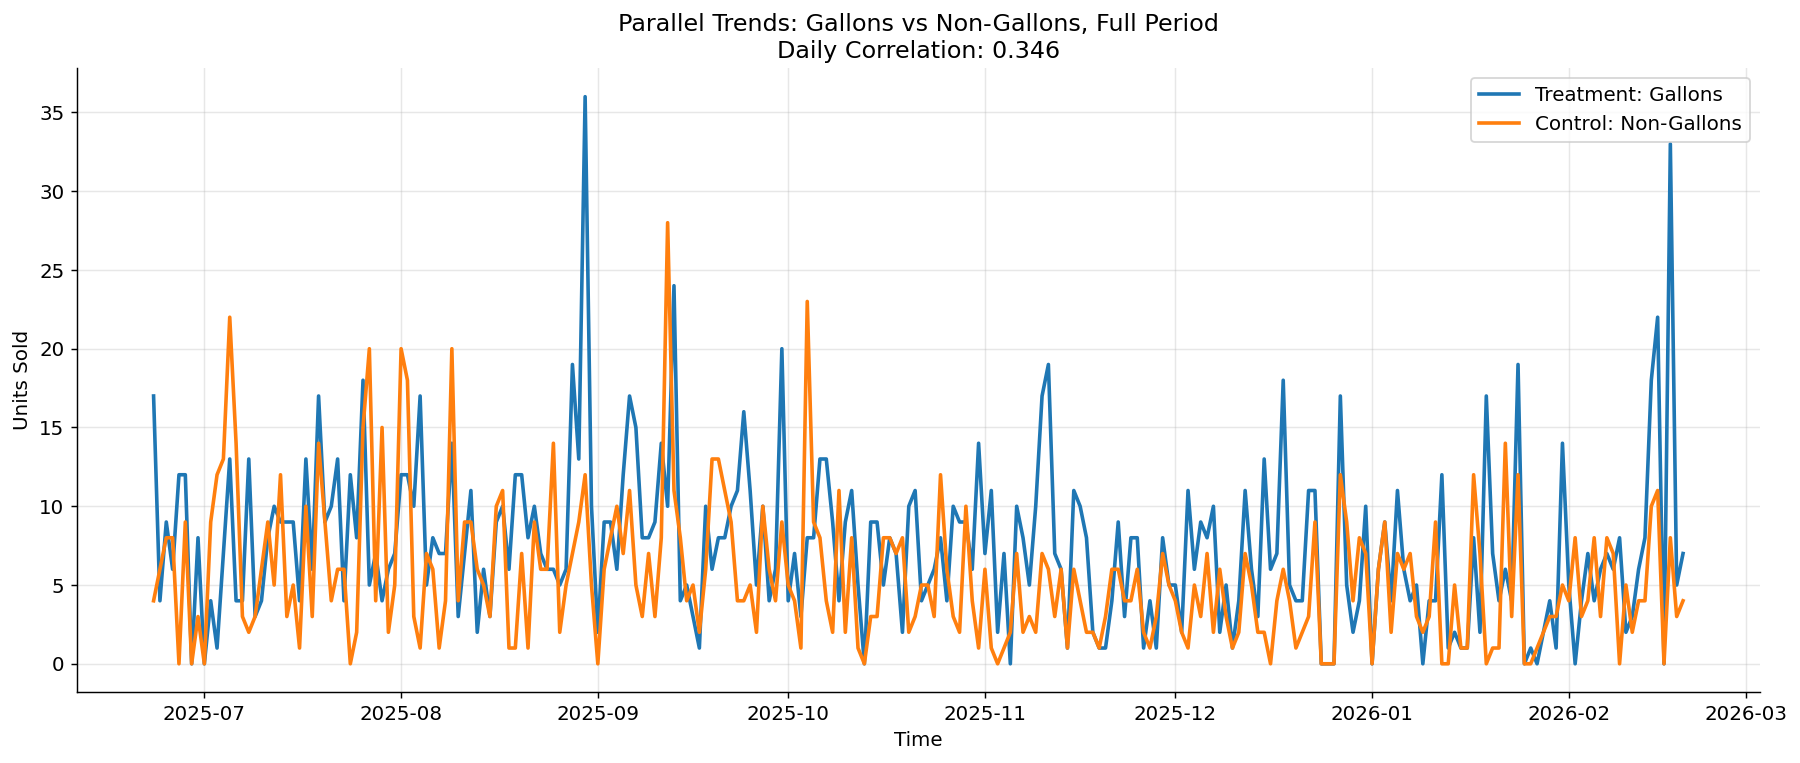

Parallel Trends: Gallons vs Non-Gallons, Full Period correlation: 0.346


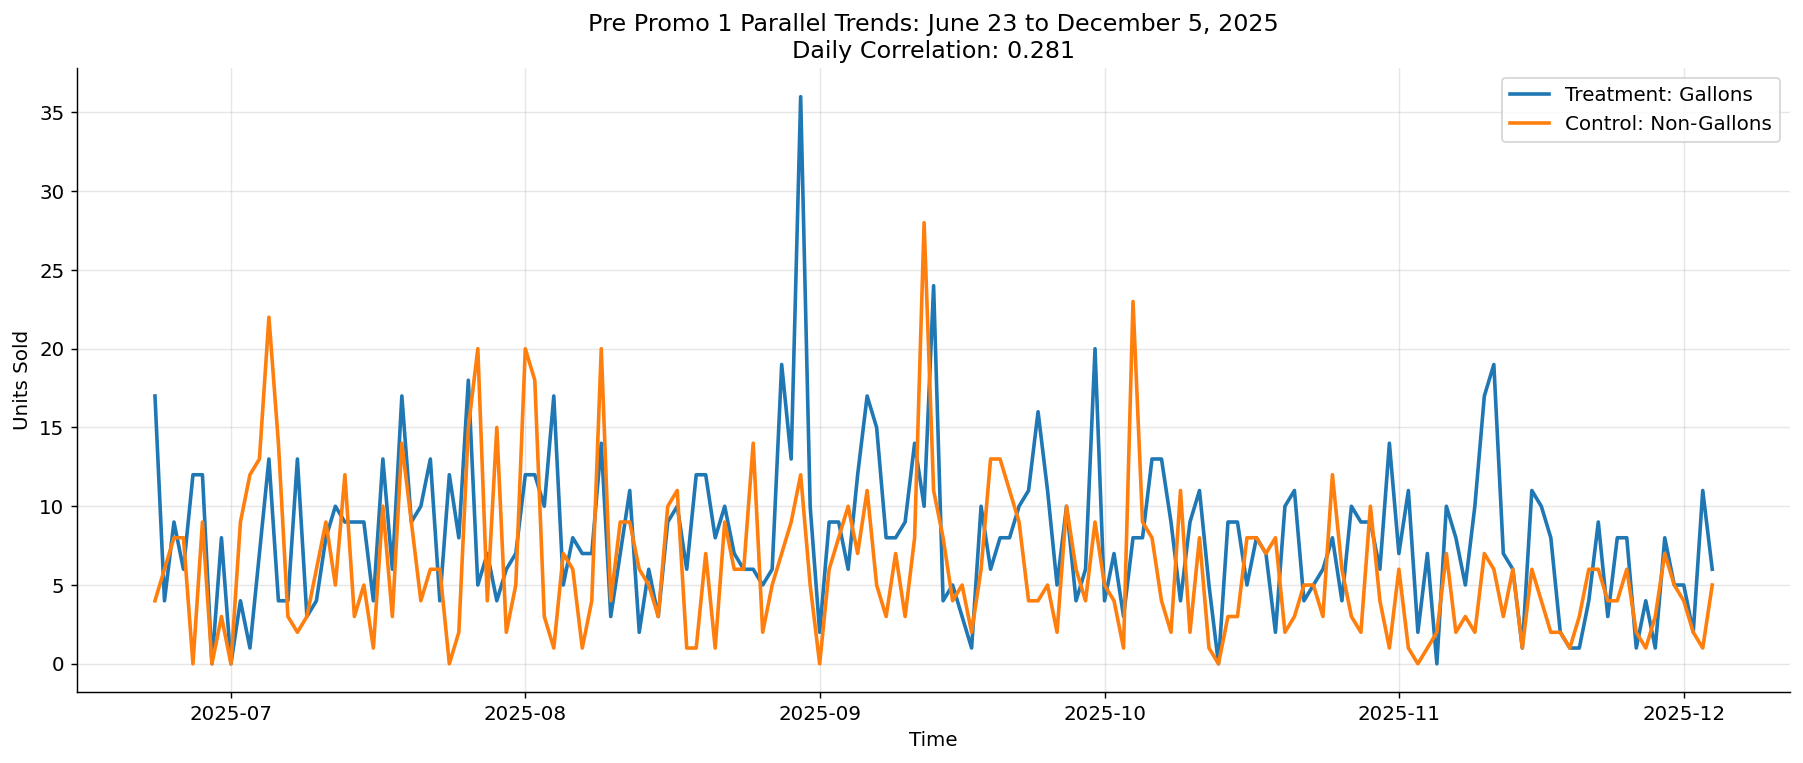

Pre Promo 1 Parallel Trends: June 23 to December 5, 2025 correlation: 0.281


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../data/feature_engineered_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Define treatment/control groups
df["Group"] = df["Size"].eq("Gallon").map({
    True: "Treatment: Gallons",
    False: "Control: Non-Gallons"
})

# Aggregate to daily units sold
daily = (
    df.groupby(["Date", "Group"])["Quantity"]
      .sum()
      .unstack(fill_value=0)
      .sort_index()
)

# Optional: include missing calendar days as 0 sales
daily = daily.asfreq("D", fill_value=0)

# Helper plotting function
def plot_parallel_trends(data, title):
    corr = data["Treatment: Gallons"].corr(data["Control: Non-Gallons"])

    plt.figure(figsize=(14, 6))

    plt.plot(
        data.index,
        data["Treatment: Gallons"],
        label="Treatment: Gallons",
        linewidth=2
    )

    plt.plot(
        data.index,
        data["Control: Non-Gallons"],
        label="Control: Non-Gallons",
        linewidth=2
    )

    plt.title(f"{title}\nDaily Correlation: {corr:.3f}")
    plt.xlabel("Time")
    plt.ylabel("Units Sold")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"{title} correlation:", round(corr, 3))


# 1. All 8 months / full available dataset
plot_parallel_trends(
    daily,
    "Parallel Trends: Gallons vs Non-Gallons, Full Period"
)


# 2. Pre Promo 1: June 23, 2026 to December 5, 2026
pre_promo_1 = daily.loc["2025-06-23":"2025-12-04"]

plot_parallel_trends(
    pre_promo_1,
    "Pre Promo 1 Parallel Trends: June 23 to December 5, 2025"
)

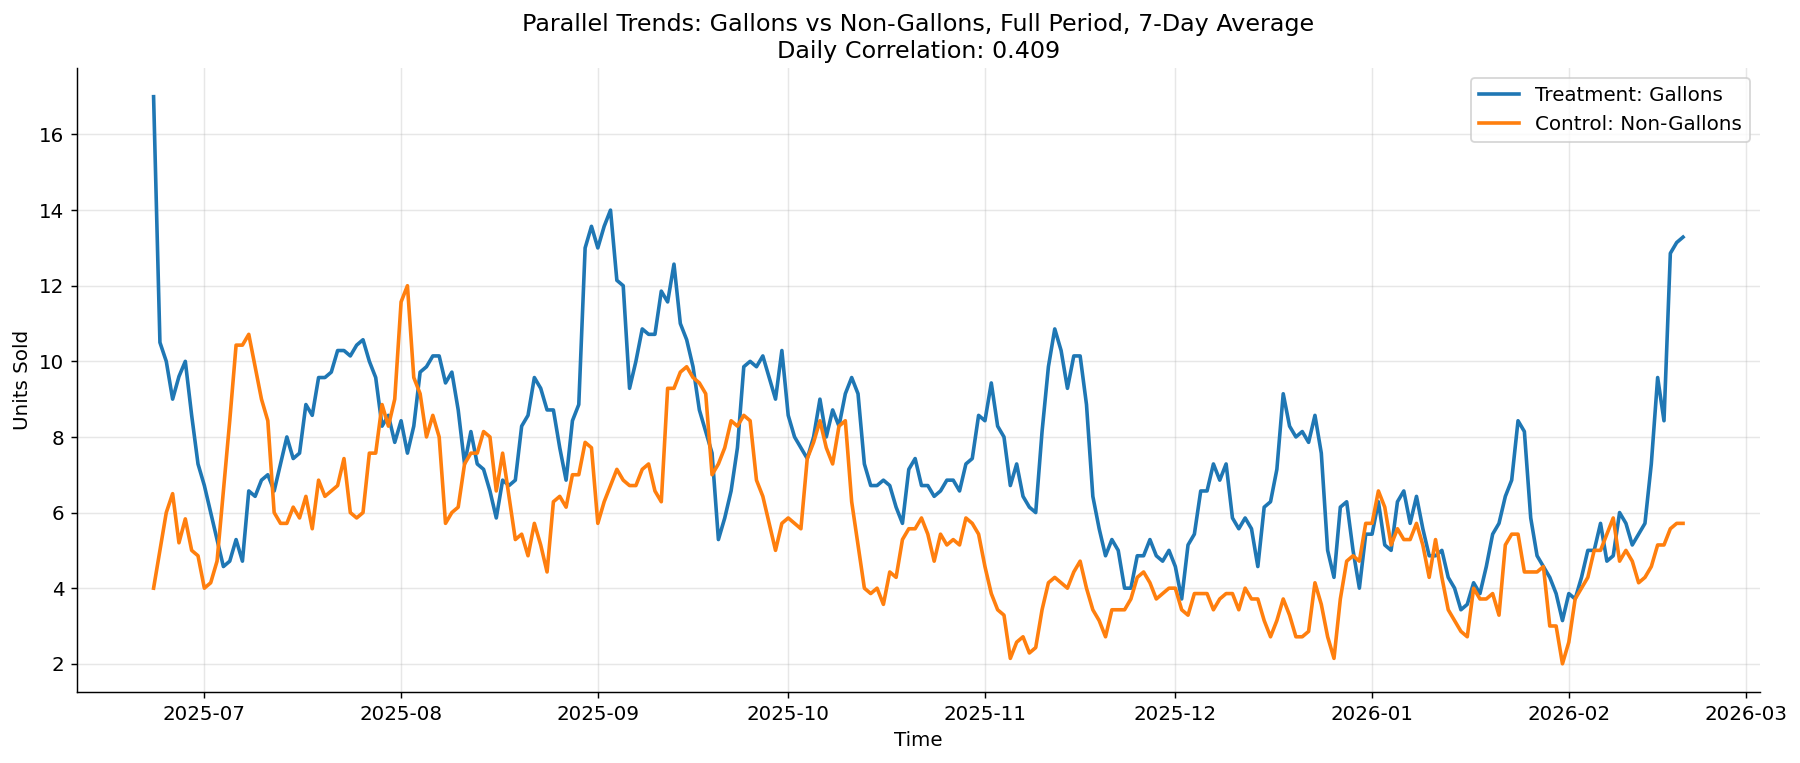

Parallel Trends: Gallons vs Non-Gallons, Full Period, 7-Day Average correlation: 0.409


In [10]:
daily_7d = daily.rolling(7, min_periods=1).mean()

plot_parallel_trends(
    daily_7d,
    "Parallel Trends: Gallons vs Non-Gallons, Full Period, 7-Day Average"
)

pre_promo_1_7d = daily_7d.loc["2026-06-23":"2026-12-05"]

---
## 2 · Outlier Check — Daily Gallon Volume
Boxplot + strip plot of total Gallons sold each day.  
Look for extreme outliers (days with unusually high volume that could distort DiD estimates).

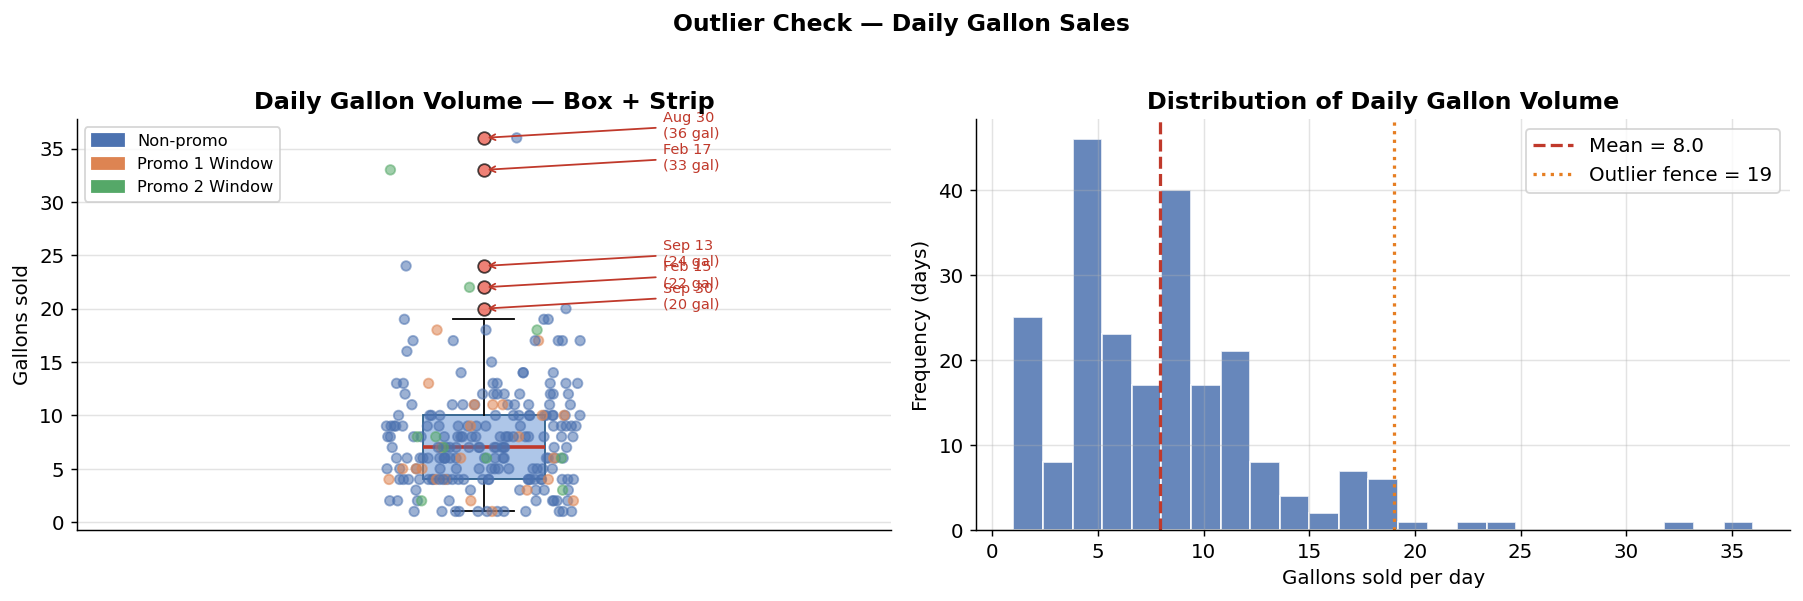

Outlier threshold (Q3 + 1.5×IQR): 19 gallons
5 outlier day(s):
      Date  Daily_Gallons         Period
2025-08-30             36      Non-promo
2025-09-13             24      Non-promo
2025-09-30             20      Non-promo
2026-02-15             22 Promo 2 Window
2026-02-17             33 Promo 2 Window


In [3]:
daily_gal = (df[df['Size'] == 'Gallon']
             .groupby('Date')['Quantity'].sum()
             .reset_index(name='Daily_Gallons'))

# Tag promo period
def period_label(d):
    if pd.Timestamp('2025-12-05') <= d <= pd.Timestamp('2025-12-31'):
        return 'Promo 1 Window'
    if pd.Timestamp('2026-02-07') <= d <= pd.Timestamp('2026-02-17'):
        return 'Promo 2 Window'
    return 'Non-promo'

daily_gal['Period'] = daily_gal['Date'].apply(period_label)

color_map = {'Non-promo': '#4C72B0', 'Promo 1 Window': '#DD8452', 'Promo 2 Window': '#55A868'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Box + strip
ax = axes[0]
ax.boxplot(daily_gal['Daily_Gallons'], vert=True, patch_artist=True,
           boxprops=dict(facecolor='#AEC6E8', color='#2c5f8a'),
           medianprops=dict(color='#c0392b', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=7, alpha=0.7))

jitter = np.random.uniform(-0.12, 0.12, len(daily_gal))
colors = daily_gal['Period'].map(color_map)
ax.scatter(1 + jitter, daily_gal['Daily_Gallons'], c=colors, alpha=0.55, s=28, zorder=3)

# Legend
handles = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
ax.legend(handles=handles, fontsize=9)
ax.set_xticks([])
ax.set_ylabel('Gallons sold')
ax.set_title('Daily Gallon Volume — Box + Strip', fontweight='bold')

# Annotate outliers
q3 = daily_gal['Daily_Gallons'].quantile(0.75)
iqr = q3 - daily_gal['Daily_Gallons'].quantile(0.25)
fence = q3 + 1.5 * iqr
outliers = daily_gal[daily_gal['Daily_Gallons'] > fence]
for _, r in outliers.iterrows():
    ax.annotate(f"{r['Date'].strftime('%b %d')}\n({int(r['Daily_Gallons'])} gal)",
                xy=(1, r['Daily_Gallons']), xytext=(1.22, r['Daily_Gallons']),
                fontsize=8, color='#c0392b',
                arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1))

# Histogram
ax = axes[1]
ax.hist(daily_gal['Daily_Gallons'], bins=25, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(daily_gal['Daily_Gallons'].mean(), color='#c0392b', linestyle='--', linewidth=1.8,
           label=f"Mean = {daily_gal['Daily_Gallons'].mean():.1f}")
ax.axvline(fence, color='#e67e22', linestyle=':', linewidth=1.8,
           label=f"Outlier fence = {fence:.0f}")
ax.legend()
ax.set_xlabel('Gallons sold per day')
ax.set_ylabel('Frequency (days)')
ax.set_title('Distribution of Daily Gallon Volume', fontweight='bold')

fig.suptitle('Outlier Check — Daily Gallon Sales', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Outlier threshold (Q3 + 1.5×IQR): {fence:.0f} gallons")
print(f"{len(outliers)} outlier day(s):")
print(outliers[['Date','Daily_Gallons','Period']].to_string(index=False))

---
## 3 · Promo-Window Verification
Daily total units sold across the full ~8-month period (Jun 2025 – Feb 2026).  
**Yellow shading = promo date window.**  
Check: do sales spikes / promo-flagged rows (red dots) land inside the yellow band?

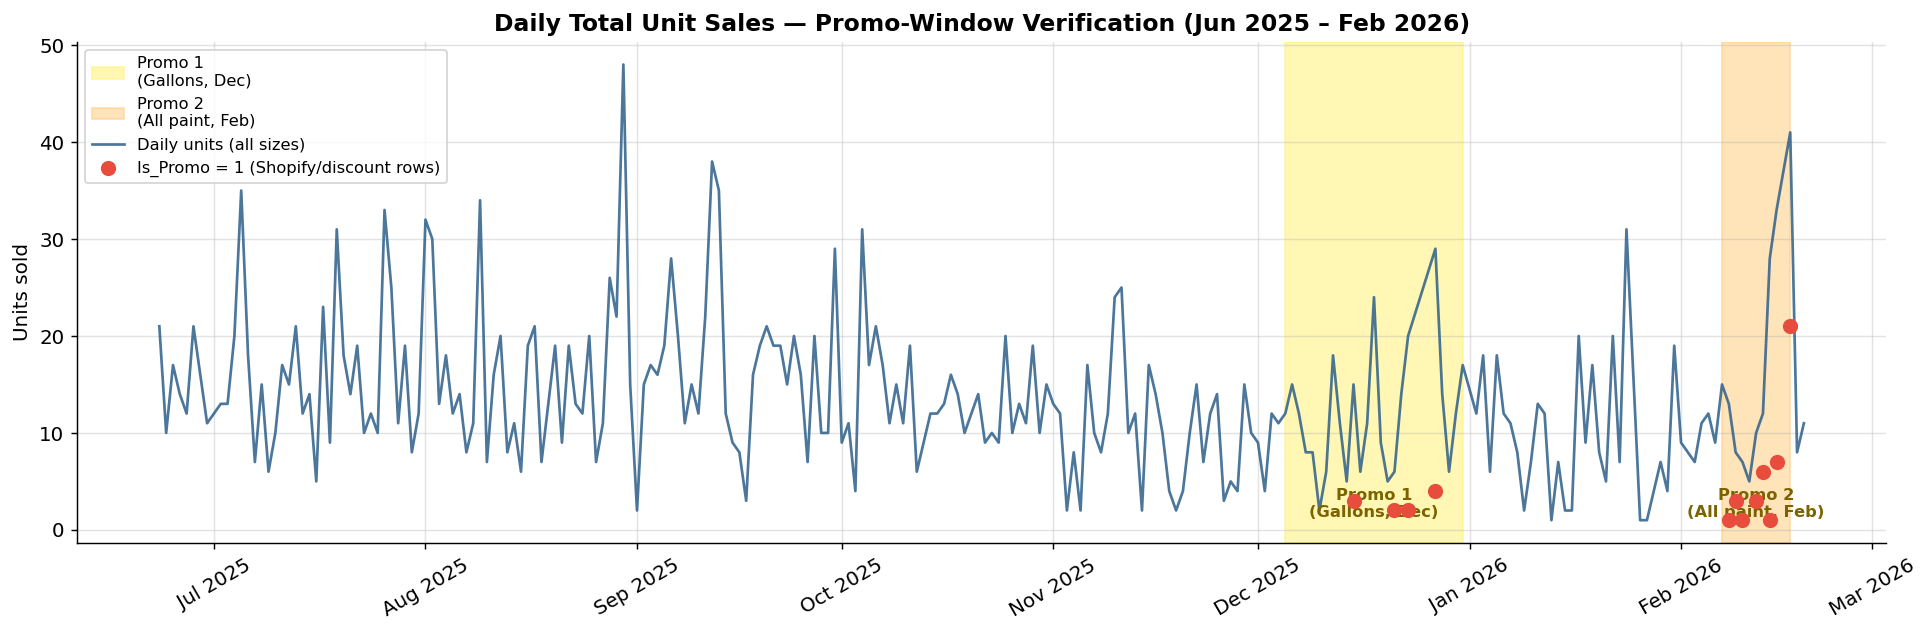

In [4]:
daily_all   = df.groupby('Date')['Quantity'].sum().reset_index(name='Total_Units')
daily_promo = df[df['Is_Promo'] == 1].groupby('Date')['Quantity'].sum().reset_index(name='Promo_Units')

fig, ax = plt.subplots(figsize=(15, 5))

# Yellow promo-window shading
shade_colors = ['#FFF176', '#FFCC80']
for (label, start, end), shade in zip(PROMO_WINDOWS, shade_colors):
    ax.axvspan(start, end, alpha=0.55, color=shade, zorder=0, label=label)
    ax.text(start + (end - start) / 2, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1,
            label, ha='center', va='bottom', fontsize=9, color='#7B6300', fontweight='bold')

# Total daily line
ax.plot(daily_all['Date'], daily_all['Total_Units'],
        color='#2c5f8a', linewidth=1.5, alpha=0.85, label='Daily units (all sizes)', zorder=2)

# Is_Promo-flagged days (red dots)
if len(daily_promo) > 0:
    ax.scatter(daily_promo['Date'], daily_promo['Promo_Units'],
               color='#e74c3c', s=55, zorder=5, label='Is_Promo = 1 (Shopify/discount rows)')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.tick_params(axis='x', rotation=30)
ax.set_ylabel('Units sold')
ax.set_title('Daily Total Unit Sales — Promo-Window Verification (Jun 2025 – Feb 2026)', fontweight='bold', fontsize=13)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

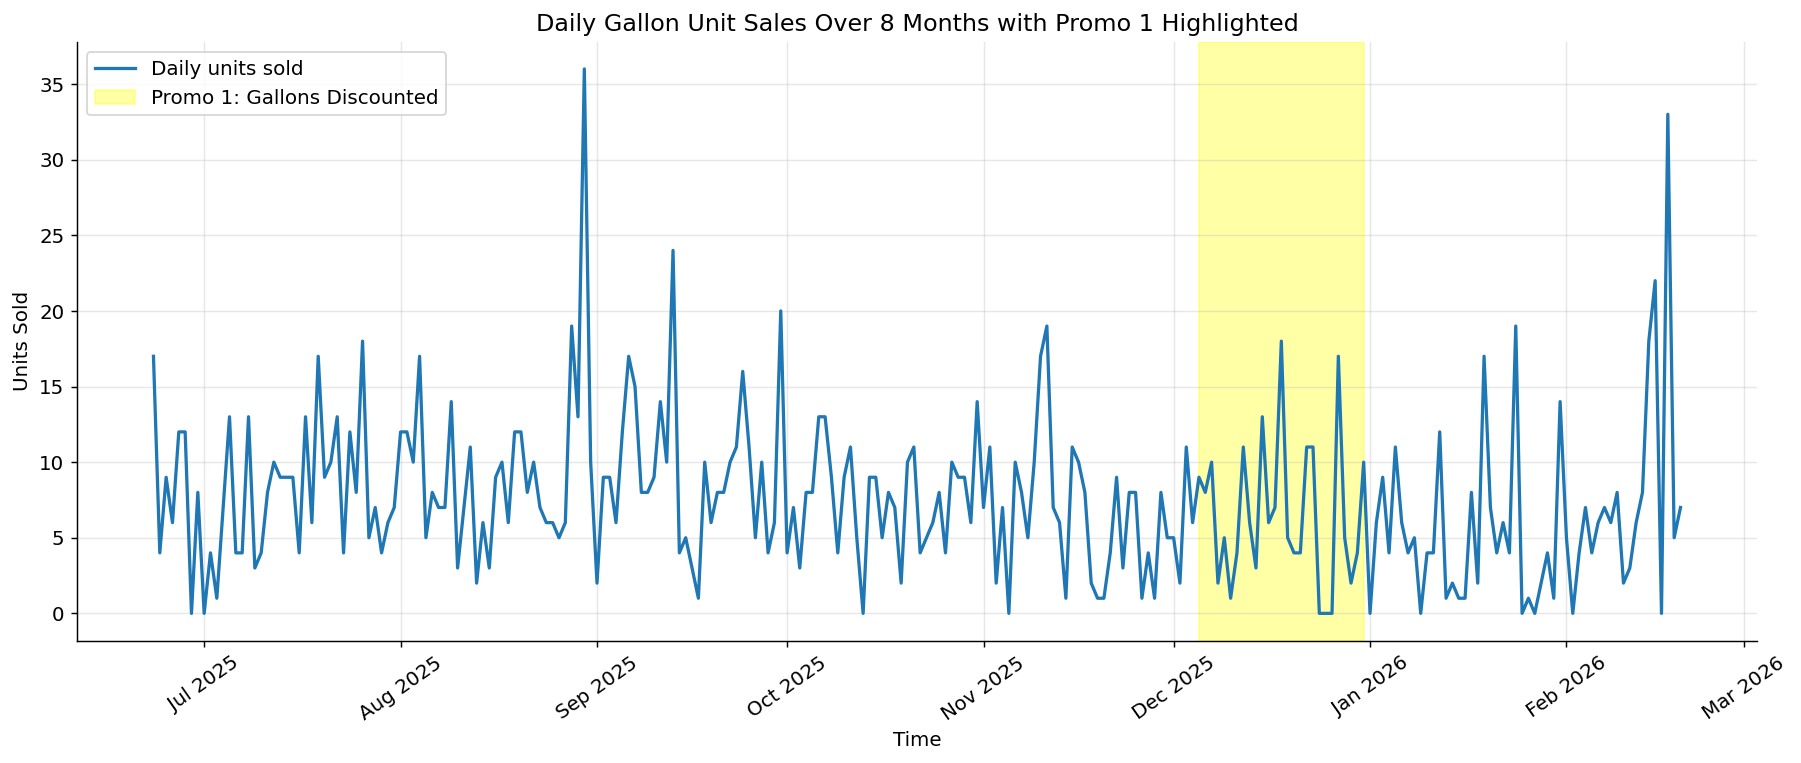

Daily Gallon Unit Sales Over 8 Months with Promo 1 Highlighted
Average daily units before promo: 8.10
Average daily units during promo: 6.52
During / before ratio: 0.80x


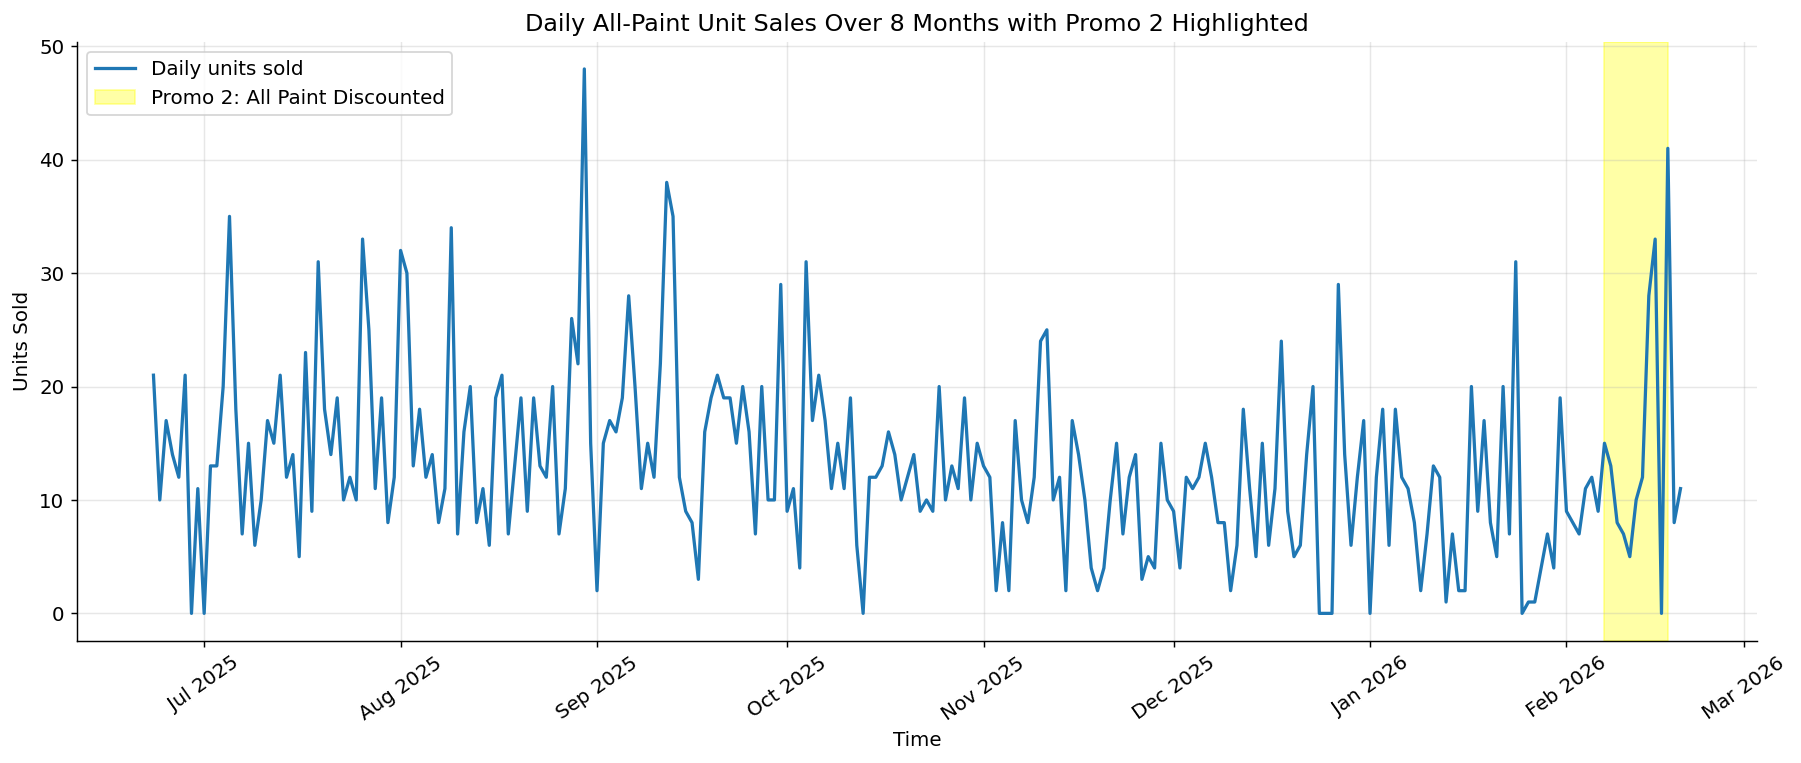

Daily All-Paint Unit Sales Over 8 Months with Promo 2 Highlighted
Average daily units before promo: 12.97
Average daily units during promo: 15.64
During / before ratio: 1.21x


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load data
df = pd.read_csv("../data/feature_engineered_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Promo windows
PROMO_1_START = pd.Timestamp("2025-12-05")
PROMO_1_END = pd.Timestamp("2025-12-31")

PROMO_2_START = pd.Timestamp("2026-02-07")
PROMO_2_END = pd.Timestamp("2026-02-17")

# Daily gallons only
daily_gallons = (
    df[df["Size"] == "Gallon"]
    .groupby("Date")["Quantity"]
    .sum()
    .sort_index()
    .asfreq("D", fill_value=0)
)

# Daily all paint
# If your dataset only contains paint products, this is fine.
# If you have non-paint sundries in the dataset, this keeps common paint container sizes only.
paint_sizes = ["Gallon", "Quart", "5 Gallon", "Quart", "Half Pint"]
daily_all_paint = (
    df[df["Size"].isin(paint_sizes)]
    .groupby("Date")["Quantity"]
    .sum()
    .sort_index()
    .asfreq("D", fill_value=0)
)

def plot_daily_sales(series, title, promo_start, promo_end, promo_label):
    plt.figure(figsize=(14, 6))

    plt.plot(
        series.index,
        series.values,
        linewidth=1.8,
        color="#1f77b4",
        label="Daily units sold"
    )

    plt.axvspan(
        promo_start,
        promo_end,
        color="yellow",
        alpha=0.35,
        label=promo_label
    )

    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Units Sold")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.xticks(rotation=35)

    plt.tight_layout()
    plt.show()

    before = series.loc[:promo_start - pd.Timedelta(days=1)].mean()
    during = series.loc[promo_start:promo_end].mean()

    print(title)
    print(f"Average daily units before promo: {before:.2f}")
    print(f"Average daily units during promo: {during:.2f}")
    print(f"During / before ratio: {during / before:.2f}x")


plot_daily_sales(
    daily_gallons,
    "Daily Gallon Unit Sales Over 8 Months with Promo 1 Highlighted",
    PROMO_1_START,
    PROMO_1_END,
    "Promo 1: Gallons Discounted"
)

plot_daily_sales(
    daily_all_paint,
    "Daily All-Paint Unit Sales Over 8 Months with Promo 2 Highlighted",
    PROMO_2_START,
    PROMO_2_END,
    "Promo 2: All Paint Discounted"
)

---
## 4 · Day-of-Week Purchase Patterns
Are there structural weekday / weekend effects that DiD must account for?

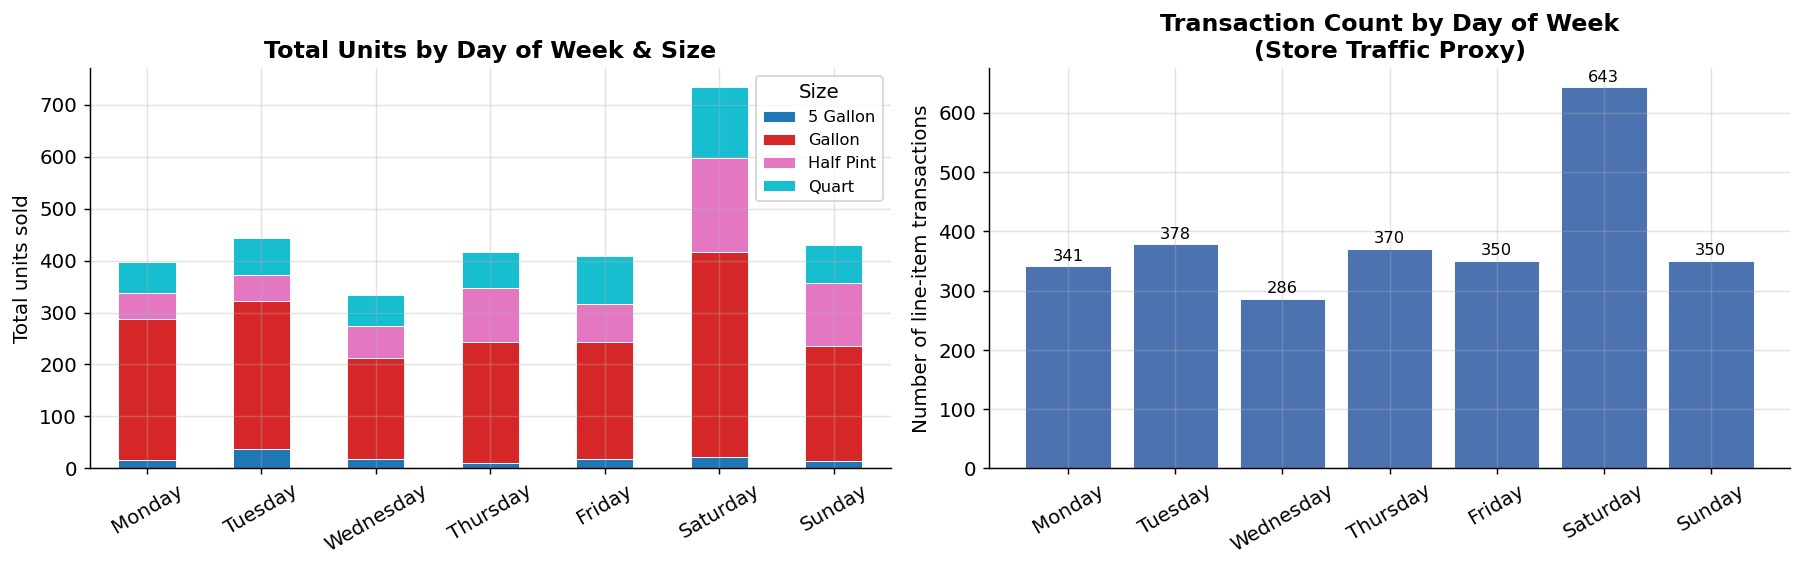

In [5]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['Day of the Week'] = pd.Categorical(df['Day of the Week'], categories=dow_order, ordered=True)

# Average daily quantity by day-of-week, by Size
dow_size = (df.groupby(['Day of the Week','Size'])['Quantity'].sum()
            .unstack('Size').fillna(0))

# Transaction count by day-of-week (store traffic proxy)
dow_txn  = df.groupby('Day of the Week').size().reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Stacked bar — total units by size & day
ax = axes[0]
dow_size.reindex(dow_order).plot(kind='bar', stacked=True, ax=ax,
                                  colormap='tab10', edgecolor='white', linewidth=0.5)
ax.set_xlabel('')
ax.set_ylabel('Total units sold')
ax.set_title('Total Units by Day of Week & Size', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Size', fontsize=9)

# Transaction count (foot traffic)
ax = axes[1]
bars = ax.bar(dow_txn.index, dow_txn.values, color='#4C72B0', edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, dow_txn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=9)
ax.set_xlabel('')
ax.set_ylabel('Number of line-item transactions')
ax.set_title('Transaction Count by Day of Week\n(Store Traffic Proxy)', fontweight='bold')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## 5 · Monthly Volume Trends & Size Mix
How does the monthly sales mix shift over time? Do Gallons dominate in promo months?

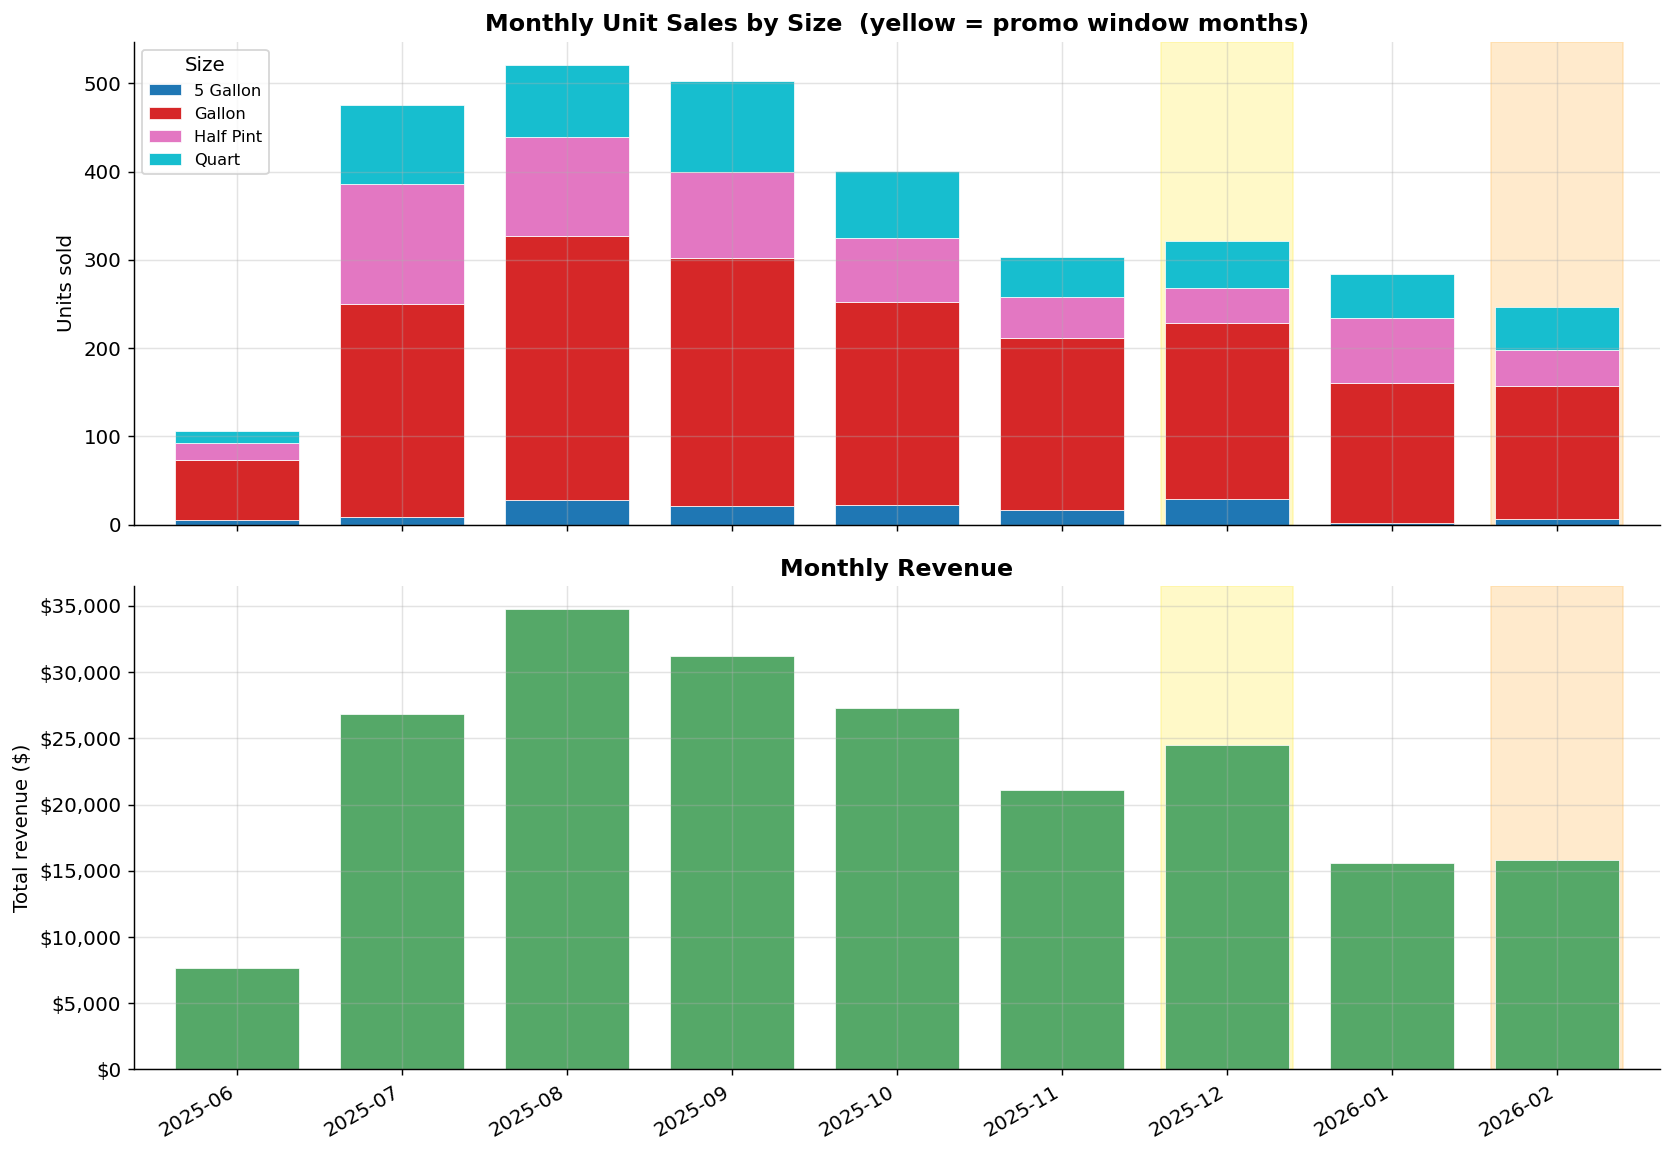

In [6]:
df['YearMonth'] = df['Date'].dt.to_period('M')

monthly_size = (df.groupby(['YearMonth','Size'])['Quantity'].sum()
                .unstack('Size').fillna(0)
                .sort_index())

monthly_rev  = (df.groupby('YearMonth')['Total Sale Price'].sum().sort_index())

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Stacked area — size mix
ax = axes[0]
monthly_size.plot(kind='bar', stacked=True, ax=ax, colormap='tab10',
                  edgecolor='white', linewidth=0.4, width=0.75)

# Shade promo windows
x_labels = [str(p) for p in monthly_size.index]
for (label, start, end), shade in zip(PROMO_WINDOWS, ['#FFF176', '#FFCC80']):
    x_idxs = [i for i, xl in enumerate(x_labels)
               if start.to_period('M') <= pd.Period(xl) <= end.to_period('M')]
    for xi in x_idxs:
        ax.axvspan(xi - 0.4, xi + 0.4, alpha=0.4, color=shade, zorder=0)

ax.set_ylabel('Units sold')
ax.set_title('Monthly Unit Sales by Size  (yellow = promo window months)', fontweight='bold')
ax.legend(title='Size', fontsize=9)
ax.tick_params(axis='x', rotation=30)

# Revenue
ax = axes[1]
ax.bar(range(len(monthly_rev)), monthly_rev.values,
       color='#55A868', edgecolor='white', linewidth=0.4, width=0.75)
for i, (label, start, end), shade in zip([0,1], PROMO_WINDOWS, ['#FFF176','#FFCC80']):
    x_idxs = [i2 for i2, xl in enumerate(x_labels)
               if start.to_period('M') <= pd.Period(xl) <= end.to_period('M')]
    for xi in x_idxs:
        ax.axvspan(xi - 0.4, xi + 0.4, alpha=0.4, color=shade, zorder=0)

ax.set_xticks(range(len(monthly_rev)))
ax.set_xticklabels(x_labels, rotation=30, ha='right')
ax.set_ylabel('Total revenue ($)')
ax.set_title('Monthly Revenue', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

---
## 6 · Customer Type Breakdown
Who is driving volume? Retail vs Contractors — and does the mix change during promos?

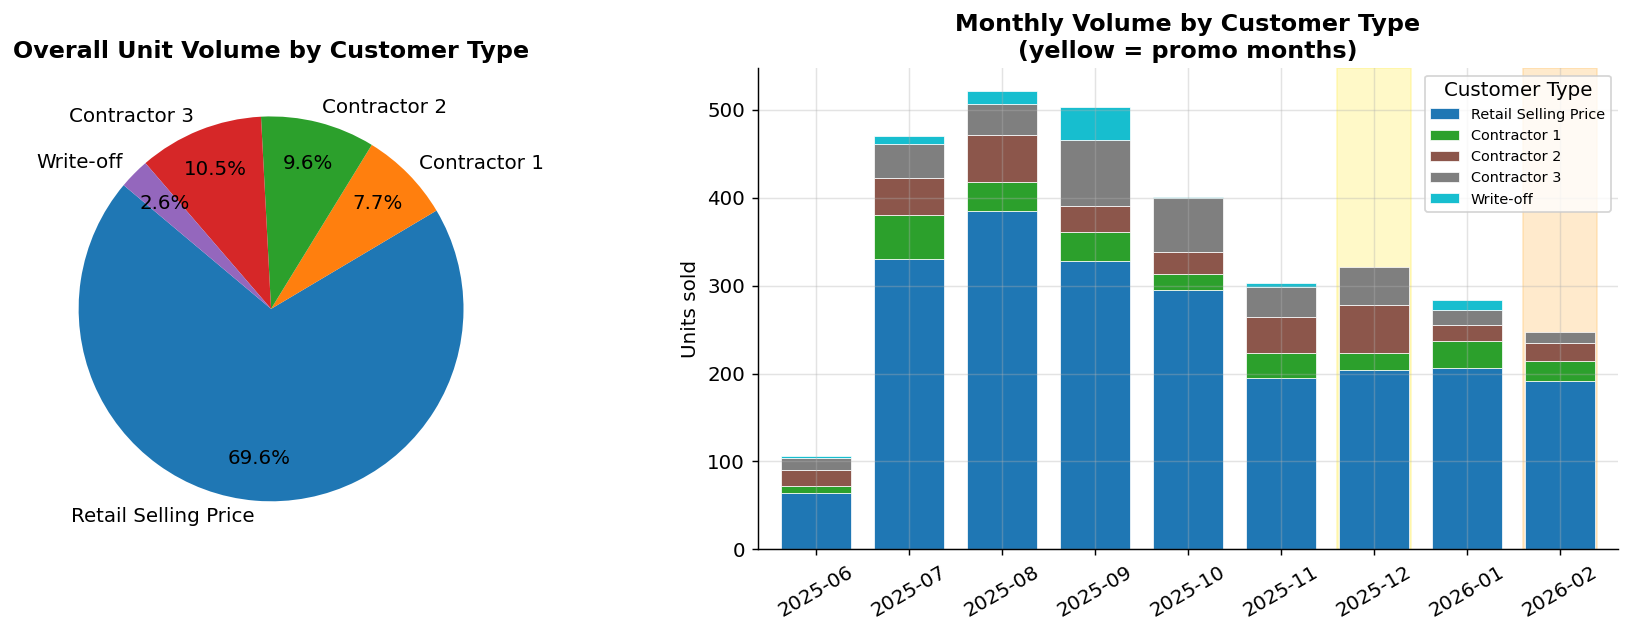

In [7]:
ctype_order = ['Retail Selling Price','Contractor 1','Contractor 2','Contractor 3','Write-off']

ctype_vol = (df.groupby(['YearMonth','Customer Type'])['Quantity'].sum()
             .unstack('Customer Type').fillna(0)
             .reindex(columns=ctype_order, fill_value=0)
             .sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall pie
ax = axes[0]
totals = df.groupby('Customer Type')['Quantity'].sum().reindex(ctype_order).fillna(0)
ax.pie(totals, labels=totals.index, autopct='%1.1f%%',
       colors=plt.cm.tab10.colors[:len(ctype_order)], startangle=140,
       pctdistance=0.78, labeldistance=1.08)
ax.set_title('Overall Unit Volume by Customer Type', fontweight='bold')

# Monthly stacked bar
ax = axes[1]
ctype_vol.plot(kind='bar', stacked=True, ax=ax, colormap='tab10',
               edgecolor='white', linewidth=0.4, width=0.75)
x_labels = [str(p) for p in ctype_vol.index]
for (label, start, end), shade in zip(PROMO_WINDOWS, ['#FFF176','#FFCC80']):
    x_idxs = [i for i, xl in enumerate(x_labels)
               if start.to_period('M') <= pd.Period(xl) <= end.to_period('M')]
    for xi in x_idxs:
        ax.axvspan(xi - 0.4, xi + 0.4, alpha=0.4, color=shade, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Units sold')
ax.set_title('Monthly Volume by Customer Type\n(yellow = promo months)', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Customer Type', fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

---
## 7 · Discount Distribution & Promo Flag Sanity Check
Verify the 15–30 % discount band correctly captures promo transactions.

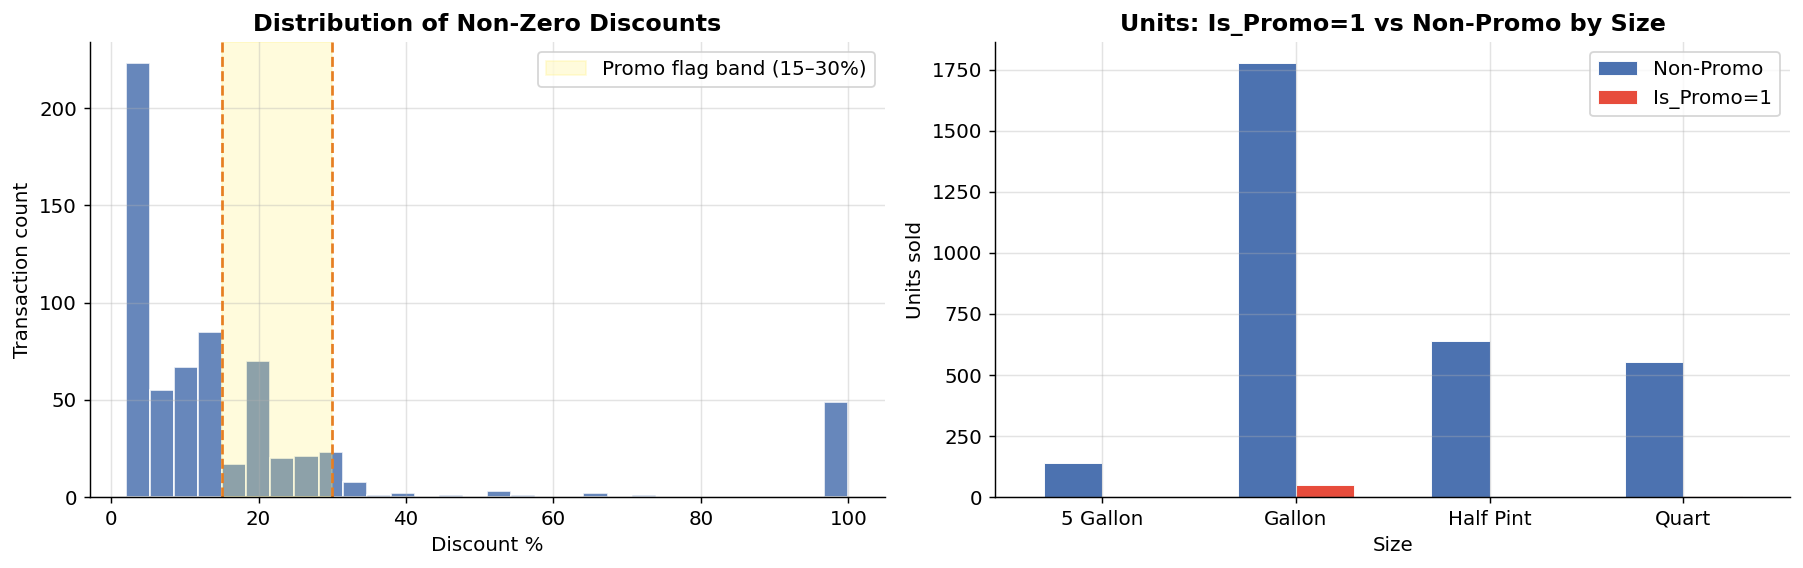

Discount_Pct stats for Is_Promo=1 rows:
count    38.000000
mean      0.203421
std       0.028596
min       0.140000
25%       0.190000
50%       0.200000
75%       0.210000
max       0.290000
Name: Discount_Pct, dtype: float64


In [8]:
discounted = df[df['Discount_Pct'] > 0.01].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Histogram of discount %
ax = axes[0]
ax.hist(discounted['Discount_Pct'] * 100, bins=30, color='#4C72B0',
        edgecolor='white', alpha=0.85)
ax.axvspan(15, 30, alpha=0.25, color='#FFF176', label='Promo flag band (15–30%)')
ax.axvline(15, color='#e67e22', linestyle='--', linewidth=1.5)
ax.axvline(30, color='#e67e22', linestyle='--', linewidth=1.5)
ax.set_xlabel('Discount %')
ax.set_ylabel('Transaction count')
ax.set_title('Distribution of Non-Zero Discounts', fontweight='bold')
ax.legend()

# Is_Promo breakdown by Size (stacked)
ax = axes[1]
promo_size = (df.groupby(['Size','Is_Promo'])['Quantity'].sum()
              .unstack('Is_Promo').fillna(0)
              .rename(columns={0:'Non-Promo', 1:'Is_Promo=1'}))
promo_size.plot(kind='bar', ax=ax, color=['#4C72B0','#e74c3c'],
                edgecolor='white', linewidth=0.5, width=0.6)
ax.set_xlabel('Size')
ax.set_ylabel('Units sold')
ax.set_title('Units: Is_Promo=1 vs Non-Promo by Size', fontweight='bold')
ax.tick_params(axis='x', rotation=0)
ax.legend()

plt.tight_layout()
plt.show()

print("Discount_Pct stats for Is_Promo=1 rows:")
print(df[df['Is_Promo']==1]['Discount_Pct'].describe())

---
## 8 · Margin & Price Analysis
Do Standard Cost and Retail Price move together? What is the typical gross margin range by size?

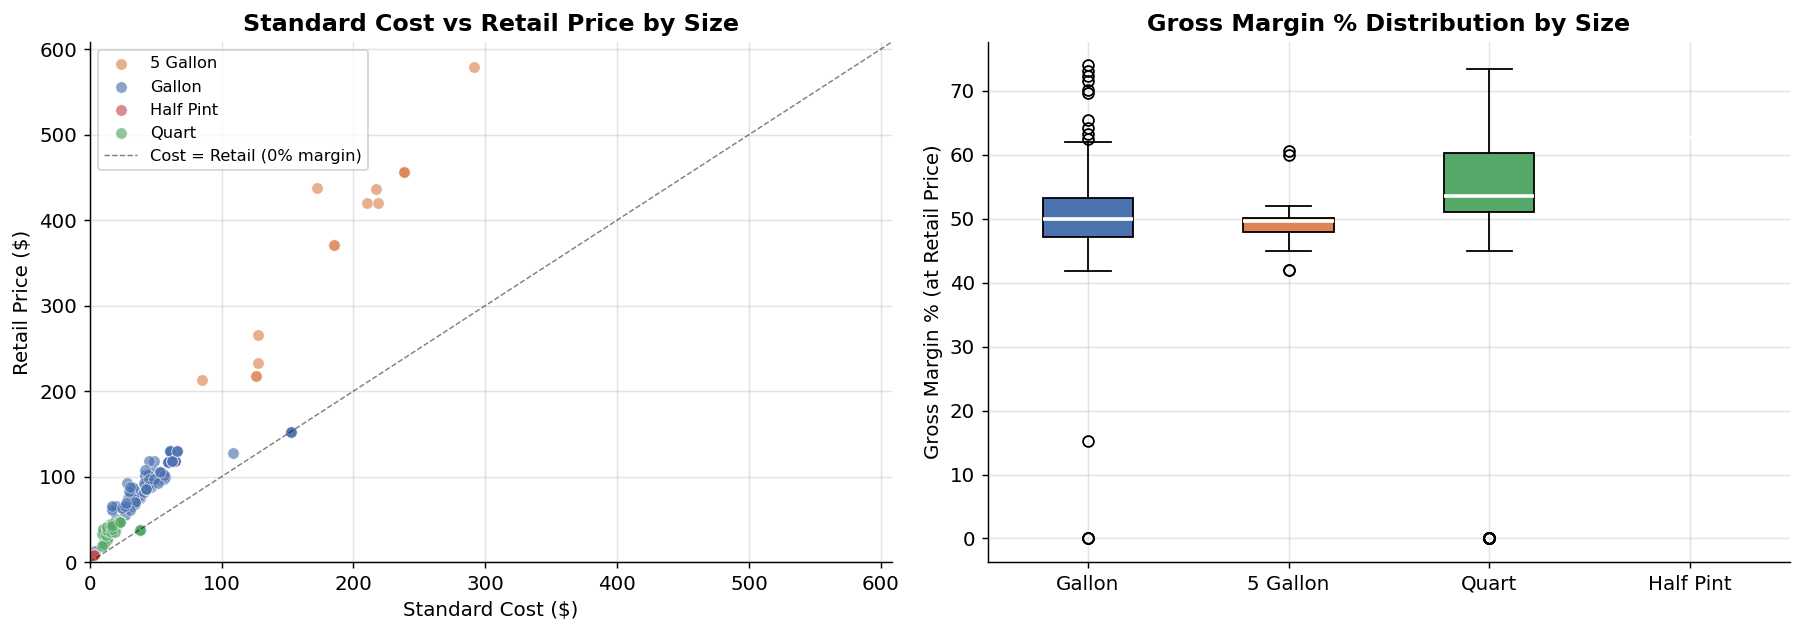

Median gross margin % by size:
Size
5 Gallon     49.7
Gallon       50.0
Half Pint    62.8
Quart        53.5


In [9]:
items = (df.drop_duplicates('Item No')
         .dropna(subset=['Standard Cost','Retail Price'])
         .copy())
items = items[items['Retail Price'] > 0]
items['Gross_Margin_Pct'] = (items['Retail Price'] - items['Standard Cost']) / items['Retail Price'] * 100

size_colors = {'Gallon':'#4C72B0','5 Gallon':'#DD8452','Quart':'#55A868','Half Pint':'#C44E52'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Cost vs Retail by Size
ax = axes[0]
for size, grp in items.groupby('Size'):
    color = size_colors.get(size, '#888')
    ax.scatter(grp['Standard Cost'], grp['Retail Price'], label=size,
               color=color, alpha=0.65, s=40, edgecolors='white', linewidth=0.4)
lims = [0, max(items['Standard Cost'].max(), items['Retail Price'].max()) * 1.05]
ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5, label='Cost = Retail (0% margin)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Standard Cost ($)')
ax.set_ylabel('Retail Price ($)')
ax.set_title('Standard Cost vs Retail Price by Size', fontweight='bold')
ax.legend(fontsize=9)

# Box: Gross margin % by size
ax = axes[1]
size_order = ['Gallon','5 Gallon','Quart','Half Pint']
data_by_size = [items[items['Size']==s]['Gross_Margin_Pct'].dropna().values for s in size_order]
bp = ax.boxplot(data_by_size, labels=size_order, patch_artist=True,
                medianprops=dict(color='white', linewidth=2))
for patch, size in zip(bp['boxes'], size_order):
    patch.set_facecolor(size_colors.get(size, '#888'))
ax.set_ylabel('Gross Margin % (at Retail Price)')
ax.set_title('Gross Margin % Distribution by Size', fontweight='bold')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Median gross margin % by size:")
print(items.groupby('Size')['Gross_Margin_Pct'].median().round(1).to_string())

---
## 9 · Post-Promo Cannibalization Window
Do sales dip in the 14 days after each promo ends (pull-forward effect)?

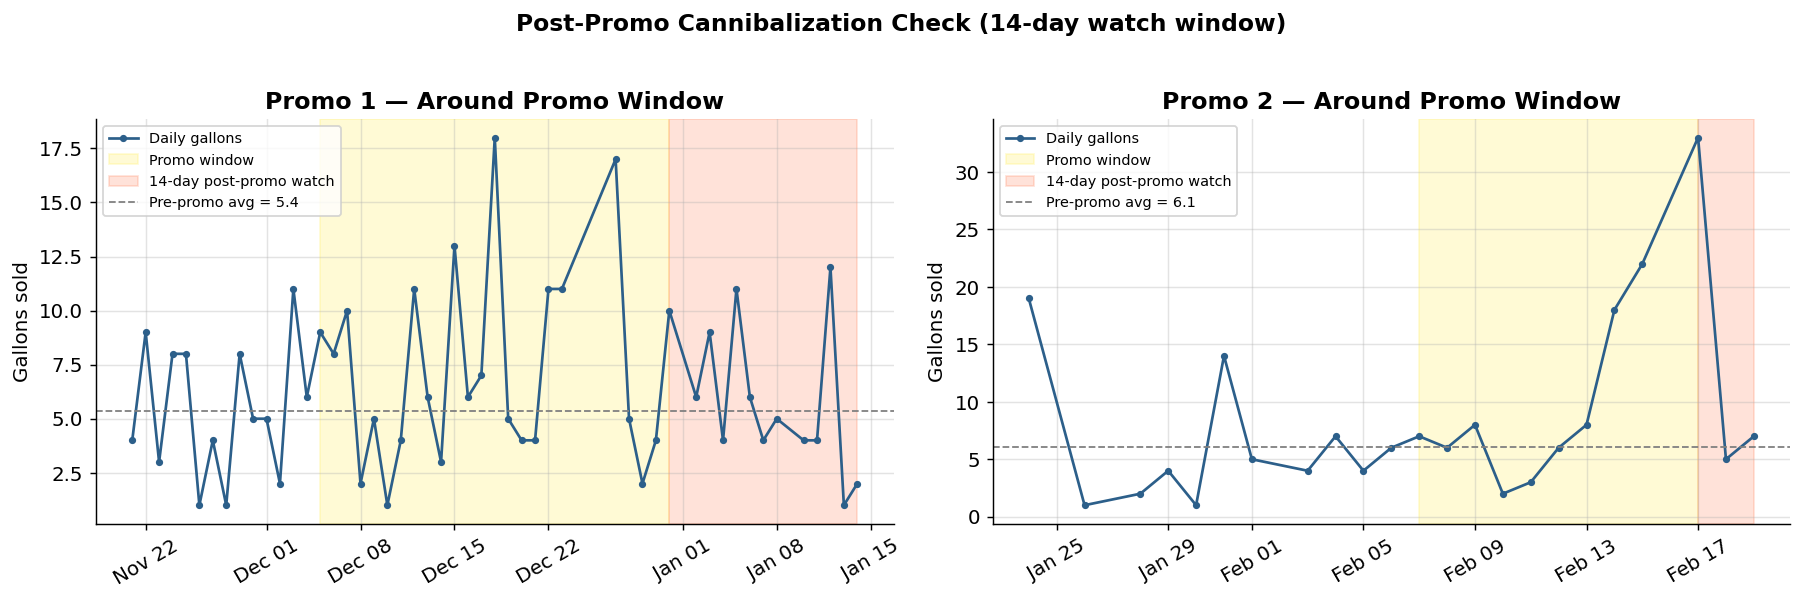

In [10]:
daily_gal_full = (df[df['Size'] == 'Gallon']
                  .groupby('Date')['Quantity'].sum()
                  .reset_index(name='Gallons'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

windows = [
    ('Promo 1', pd.Timestamp('2025-11-21'), pd.Timestamp('2026-01-14'),
     pd.Timestamp('2025-12-05'), pd.Timestamp('2025-12-31')),
    ('Promo 2', pd.Timestamp('2026-01-24'), pd.Timestamp('2026-02-19'),
     pd.Timestamp('2026-02-07'), pd.Timestamp('2026-02-17')),
]

for ax, (label, view_start, view_end, promo_start, promo_end) in zip(axes, windows):
    sub = daily_gal_full[(daily_gal_full['Date'] >= view_start) &
                         (daily_gal_full['Date'] <= view_end)]
    ax.plot(sub['Date'], sub['Gallons'], color='#2c5f8a', linewidth=1.5, marker='o',
            markersize=3, label='Daily gallons')
    ax.axvspan(promo_start, promo_end, alpha=0.3, color='#FFF176', label='Promo window')
    if promo_end <= view_end:
        cannibal_end = min(promo_end + pd.Timedelta(days=14), view_end)
        ax.axvspan(promo_end, cannibal_end, alpha=0.2, color='#FF7043',
                   label='14-day post-promo watch')
    pre_avg = sub[sub['Date'] < promo_start]['Gallons'].mean()
    ax.axhline(pre_avg, color='grey', linestyle='--', linewidth=1,
               label=f'Pre-promo avg = {pre_avg:.1f}')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=30)
    ax.set_title(f'{label} — Around Promo Window', fontweight='bold')
    ax.set_ylabel('Gallons sold')
    ax.legend(fontsize=8)

fig.suptitle('Post-Promo Cannibalization Check (14-day watch window)', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 10 · Summary — Key EDA Takeaways
Run the cell below to auto-print a summary of all numeric findings above.

In [11]:
print('=' * 62)
print('  EDA SUMMARY')
print('=' * 62)

corr_val = parallel.corr().iloc[0, 1] if isinstance(parallel, pd.DataFrame) else float('nan')
print(f"\n[Parallel Trends]")
print(f"  Weekly Gallon vs Control Pearson corr: {corr_val:.3f}")
if corr_val >= 0.7:
    print("  → GOOD: Trends appear to move together.")
elif corr_val >= 0.4:
    print("  → MODERATE: Some co-movement but noisy. Review indexed chart.")
else:
    print("  → WEAK: Parallel trends assumption is questionable — consider re-specifying control group.")

print(f"\n[Outlier Check — Daily Gallons]")
print(f"  Mean: {daily_gal['Daily_Gallons'].mean():.1f}  |  Median: {daily_gal['Daily_Gallons'].median():.0f}  |  Max: {daily_gal['Daily_Gallons'].max():.0f}")
print(f"  Outlier fence (Q3 + 1.5×IQR): {fence:.0f}")
print(f"  Outlier days: {len(outliers)}")
if len(outliers):
    for _, r in outliers.iterrows():
        print(f"    {r['Date'].date()} — {int(r['Daily_Gallons'])} gal ({r['Period']})")

print(f"\n[Promo Flags]")
print(f"  Is_Promo_1 rows (Shopify, 15-30% disc, Dec, Gallon): {df['Is_Promo_1'].sum()}")
print(f"  Is_Promo_2 rows (Shopify, 15-30% disc, Feb):         {df['Is_Promo_2'].sum()}")
print(f"  Note: Low flag counts mean very few Shopify-discounted transactions")
print(f"  were in the data. Consider widening Is_Promo to cover the full date")
print(f"  windows (all customers) for DiD — the flag may be too narrow.")

print(f"\n[Gross Margin]")
med_margin = items.groupby('Size')['Gross_Margin_Pct'].median().round(1)
for size, m in med_margin.items():
    print(f"  {size}: {m}%")

print('\n' + '=' * 62)

  EDA SUMMARY

[Parallel Trends]
  Weekly Gallon vs Control Pearson corr: 0.377
  → WEAK: Parallel trends assumption is questionable — consider re-specifying control group.

[Outlier Check — Daily Gallons]
  Mean: 8.0  |  Median: 7  |  Max: 36
  Outlier fence (Q3 + 1.5×IQR): 19
  Outlier days: 5
    2025-08-30 — 36 gal (Non-promo)
    2025-09-13 — 24 gal (Non-promo)
    2025-09-30 — 20 gal (Non-promo)
    2026-02-15 — 22 gal (Promo 2 Window)
    2026-02-17 — 33 gal (Promo 2 Window)

[Promo Flags]
  Is_Promo_1 rows (Shopify, 15-30% disc, Dec, Gallon): 6
  Is_Promo_2 rows (Shopify, 15-30% disc, Feb):         32
  Note: Low flag counts mean very few Shopify-discounted transactions
  were in the data. Consider widening Is_Promo to cover the full date
  windows (all customers) for DiD — the flag may be too narrow.

[Gross Margin]
  5 Gallon: 49.7%
  Gallon: 50.0%
  Half Pint: 62.8%
  Quart: 53.5%



## Correlation Matrix (Pre-Promo 1)

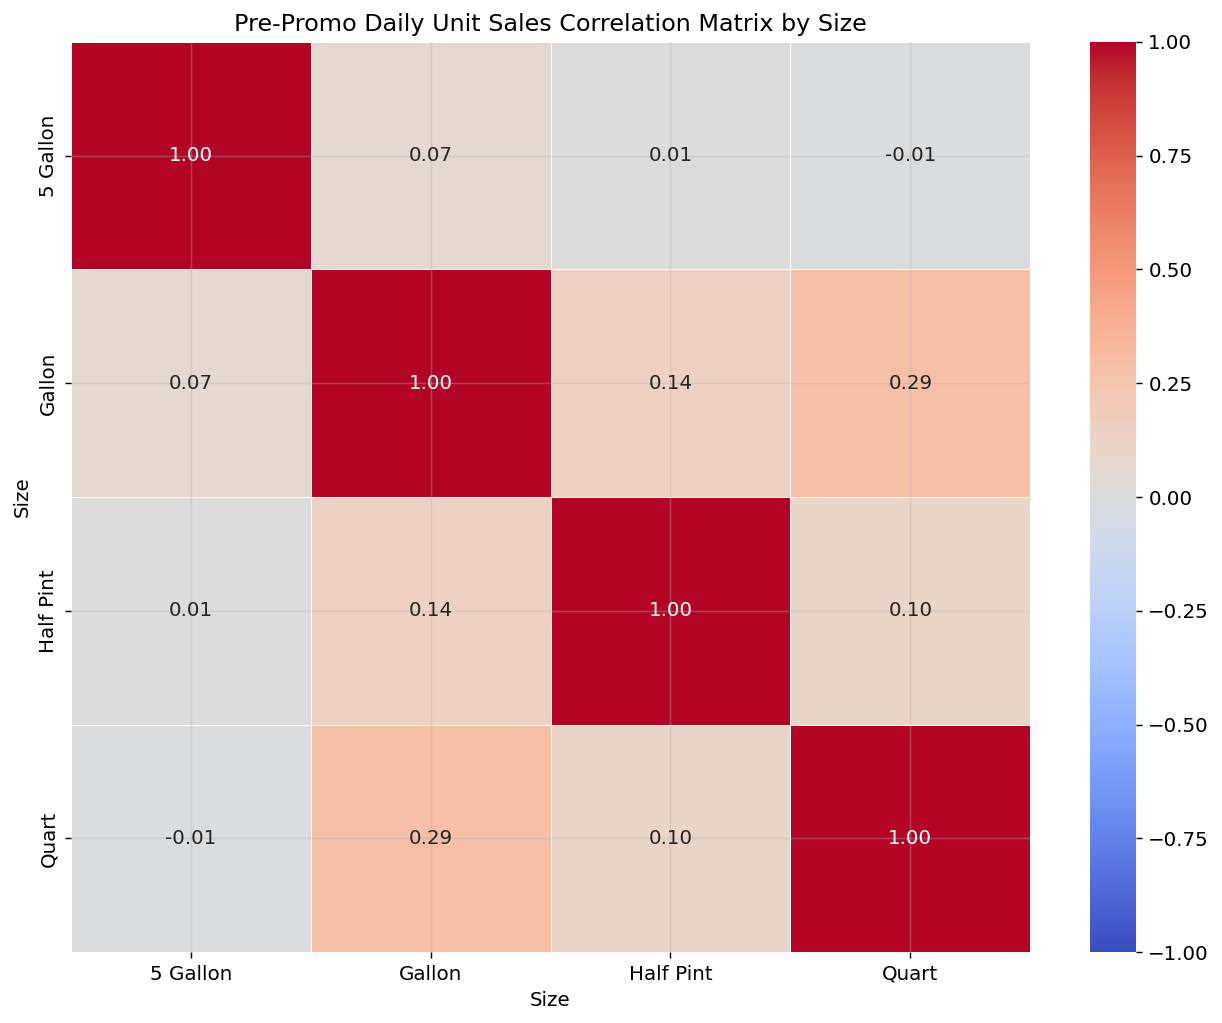

Correlation with Gallon during pre-promo period:
Size
Quart        0.285105
Half Pint    0.136720
5 Gallon     0.065649
Name: Gallon, dtype: float64


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data if df is not already loaded
df = pd.read_csv("../data/feature_engineered_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Use only pre-promo period for choosing a control group
# Promo 1 starts on Dec 5, 2025
pre_promo = df[
    (df["Date"] >= "2025-06-23") &
    (df["Date"] < "2025-12-05")
].copy()

# Daily unit sales by Size
daily_by_size = (
    pre_promo
    .groupby(["Date", "Size"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
    .asfreq("D", fill_value=0)
)

# Optional: remove very low-volume categories that may create noisy correlations
min_total_units = 20
daily_by_size = daily_by_size.loc[:, daily_by_size.sum() >= min_total_units]

# Correlation matrix
corr_matrix = daily_by_size.corr()

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Pre-Promo Daily Unit Sales Correlation Matrix by Size")
plt.tight_layout()
plt.show()

# Show correlations with Gallon, sorted
gallon_corrs = (
    corr_matrix["Gallon"]
    .drop("Gallon")
    .sort_values(ascending=False)
)

print("Correlation with Gallon during pre-promo period:")
print(gallon_corrs)

## ITS (Interrupted Time Series)

Window: 1 month before promo, 2 weeks after for cannibilization dip

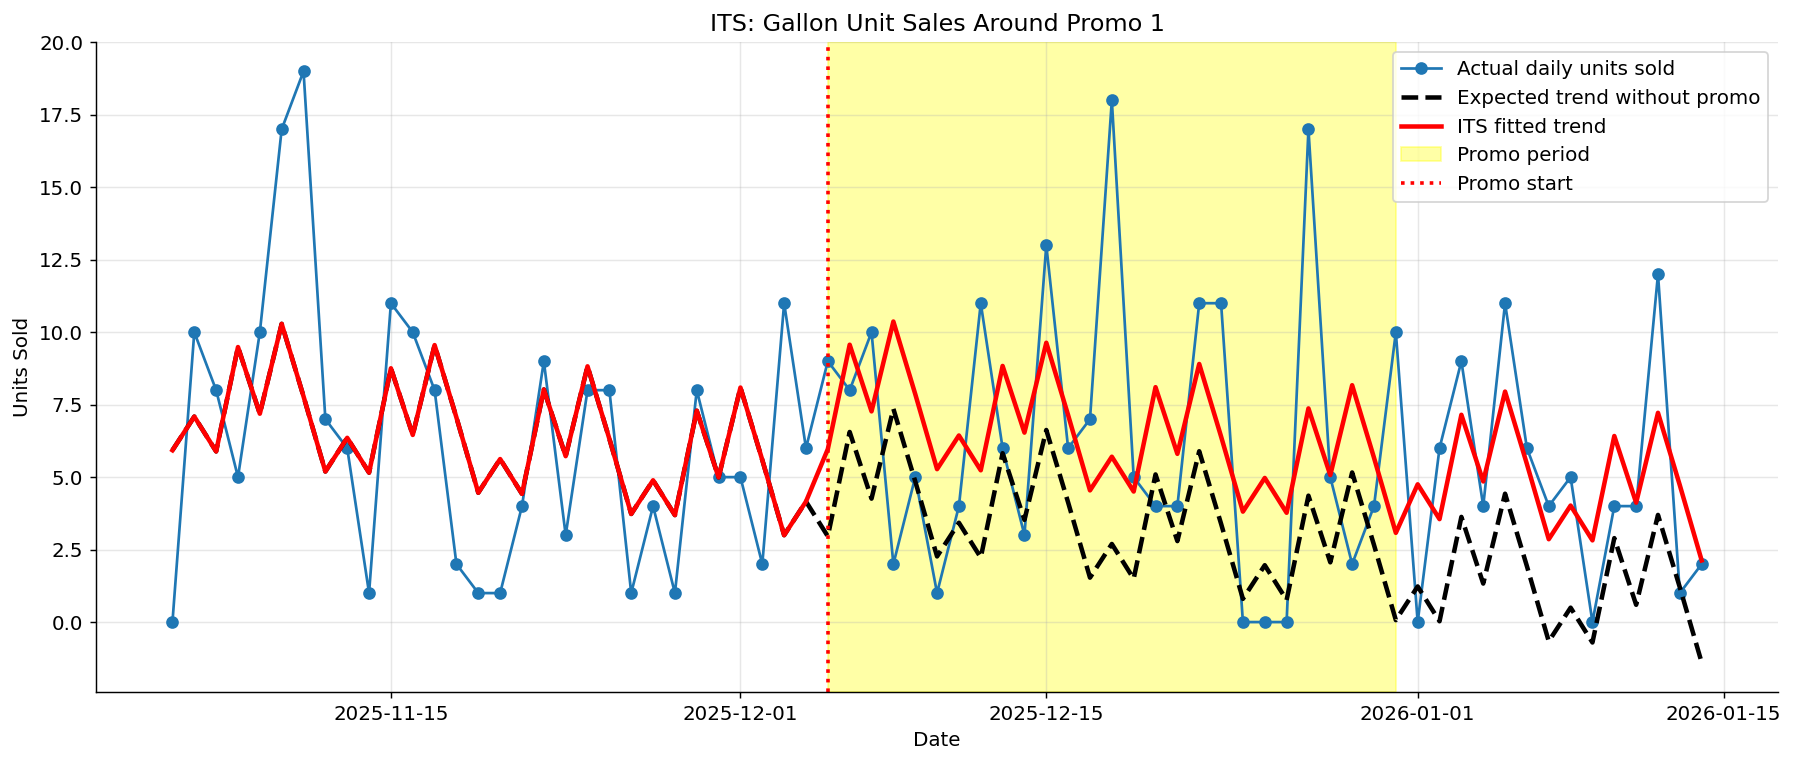


ITS: Gallon Unit Sales Around Promo 1
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       6.0965      1.756      3.471      0.001       2.585       9.608
C(day_of_week)[T.Monday]        4.7139      1.983      2.378      0.021       0.749       8.678
C(day_of_week)[T.Saturday]      3.7046      1.973      1.878      0.065      -0.240       7.649
C(day_of_week)[T.Sunday]        1.5093      1.976      0.764      0.448      -2.443       5.461
C(day_of_week)[T.Thursday]      1.0964      1.979      0.554      0.582      -2.861       5.054
C(day_of_week)[T.Tuesday]       2.3185      1.991      1.164      0.249      -1.663       6.300
C(day_of_week)[T.Wednesday]    -0.1695      1.942     -0.087      0.931      -4.053       3.713
time                           -0.1046      0.070     -1.500      0.139      -0.244       0.035
i

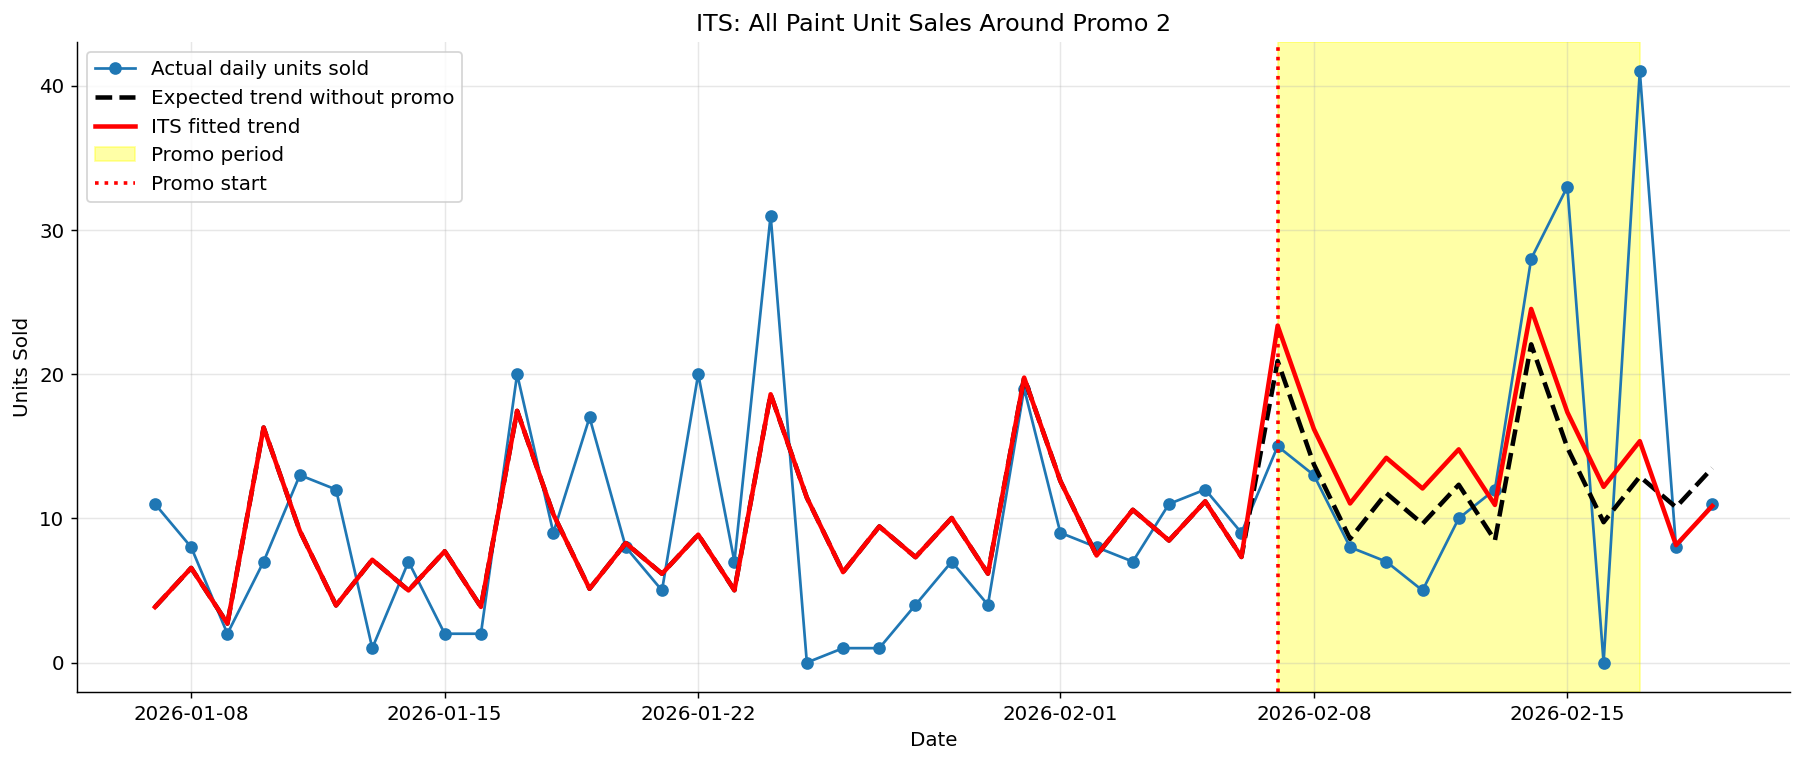


ITS: All Paint Unit Sales Around Promo 2
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       2.3768      4.279      0.556      0.582      -6.318      11.072
C(day_of_week)[T.Monday]        0.7633      4.774      0.160      0.874      -8.938      10.465
C(day_of_week)[T.Saturday]     13.4263      4.791      2.803      0.008       3.691      23.162
C(day_of_week)[T.Sunday]        6.0948      4.779      1.275      0.211      -3.618      15.808
C(day_of_week)[T.Thursday]      4.0220      4.665      0.862      0.395      -5.459      13.503
C(day_of_week)[T.Tuesday]       3.7651      4.774      0.789      0.436      -5.937      13.467
C(day_of_week)[T.Wednesday]     1.4725      4.674      0.315      0.755      -8.026      10.971
time                            0.1648      0.163      1.012      0.319      -0.166       0.49

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Load data
df = pd.read_csv("../data/feature_engineered_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Promo windows
PROMO_1_START = pd.Timestamp("2025-12-05")
PROMO_1_END = pd.Timestamp("2025-12-31")

PROMO_2_START = pd.Timestamp("2026-02-07")
PROMO_2_END = pd.Timestamp("2026-02-17")


def run_its_plot(data, title, window_start, window_end, promo_start, promo_end):
    """
    Interrupted Time Series:
    Quantity = intercept + time trend + promo level shift + promo slope change
    """

    # Daily sales
    daily = (
        data.groupby("Date")["Quantity"]
        .sum()
        .sort_index()
        # Forces df to have row for every calendar day even if no sales that day
        .asfreq("D", fill_value=0)
        .reset_index()
    )

    # Keep local window
    daily = daily[
        (daily["Date"] >= window_start) &
        (daily["Date"] <= window_end)
    ].copy()

    # ITS variables
    # Base time trend (the slow winter decline)
    daily["time"] = np.arange(len(daily))
    
    # Add Day of Week to handle weekend spikes
    daily["day_of_week"] = daily["Date"].dt.day_name()
    
    # Fix the Promo Pulse (Only 1 during the promo dates)
    daily["is_promo"] = (
        (daily["Date"] >= promo_start) & (daily["Date"] <= promo_end)
    ).astype(int)
    
    # Add the Cannibalization Window (Only 1 after the promo ends)
    daily["is_post_promo"] = (daily["Date"] > promo_end).astype(int)

    # Regression: time trend + promo lift + post-promo dip + weekly seasonality
    model = smf.ols(
        "Quantity ~ time + is_promo + is_post_promo + C(day_of_week)",
        data=daily
    ).fit()

    # Predictions
    daily["fitted_its"] = model.predict(daily)

    # Counterfactual trend: what the pre-promo trend predicts without promo (setting promo and post-promo to 0)
    counterfactual = daily.copy()
    counterfactual["is_promo"] = 0
    counterfactual["is_post_promo"] = 0
    daily["counterfactual_no_promo"] = model.predict(counterfactual)

    # Plot
    plt.figure(figsize=(14, 6))

    plt.plot(
        daily["Date"],
        daily["Quantity"],
        marker="o",
        linewidth=1.5,
        label="Actual daily units sold"
    )

    plt.plot(
        daily["Date"],
        daily["counterfactual_no_promo"],
        linestyle="--",
        linewidth=2.5,
        color="black",
        label="Expected trend without promo"
    )

    plt.plot(
        daily["Date"],
        daily["fitted_its"],
        linewidth=2.5,
        color="red",
        label="ITS fitted trend"
    )

    plt.axvspan(
        promo_start,
        promo_end,
        color="yellow",
        alpha=0.35,
        label="Promo period"
    )

    plt.axvline(
        promo_start,
        color="red",
        linestyle=":",
        linewidth=2,
        label="Promo start"
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Units Sold")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n" + title)
    print(model.summary().tables[1])

    print("\nInterpretation:")
    print(f"Pre-promo daily trend slope: {model.params['time']:.3f} units/day")
    
    # Updated to match the new variable name 'is_promo'
    print(f"Promo level change: {model.params['is_promo']:.3f} units")
    
    # Updated to match the new variable name 'is_post_promo'
    print(f"Post-promo cannibalization dip: {model.params['is_post_promo']:.3f} units")


# -------------------------
# Graph 1: Promo 1, Gallons only
# -------------------------
gallons_only = df[df["Size"] == "Gallon"].copy()

run_its_plot(
    data=gallons_only,
    title="ITS: Gallon Unit Sales Around Promo 1",
    window_start=pd.Timestamp("2025-11-05"),
    window_end=pd.Timestamp("2026-01-14"),
    promo_start=PROMO_1_START,
    promo_end=PROMO_1_END
)


# -------------------------
# Graph 2: Promo 2, All paint
# -------------------------
# Adjust this list if your Size values differ
paint_sizes = ["Gallon", "5 Gallon", "Quart", "Pint", "Half Pint", "Sample"]

all_paint = df[df["Size"].isin(paint_sizes)].copy()

run_its_plot(
    data=all_paint,
    title="ITS: All Paint Unit Sales Around Promo 2",
    window_start=pd.Timestamp("2026-01-07"),
    window_end=pd.Timestamp("2026-03-03"),
    promo_start=PROMO_2_START,
    promo_end=PROMO_2_END
)

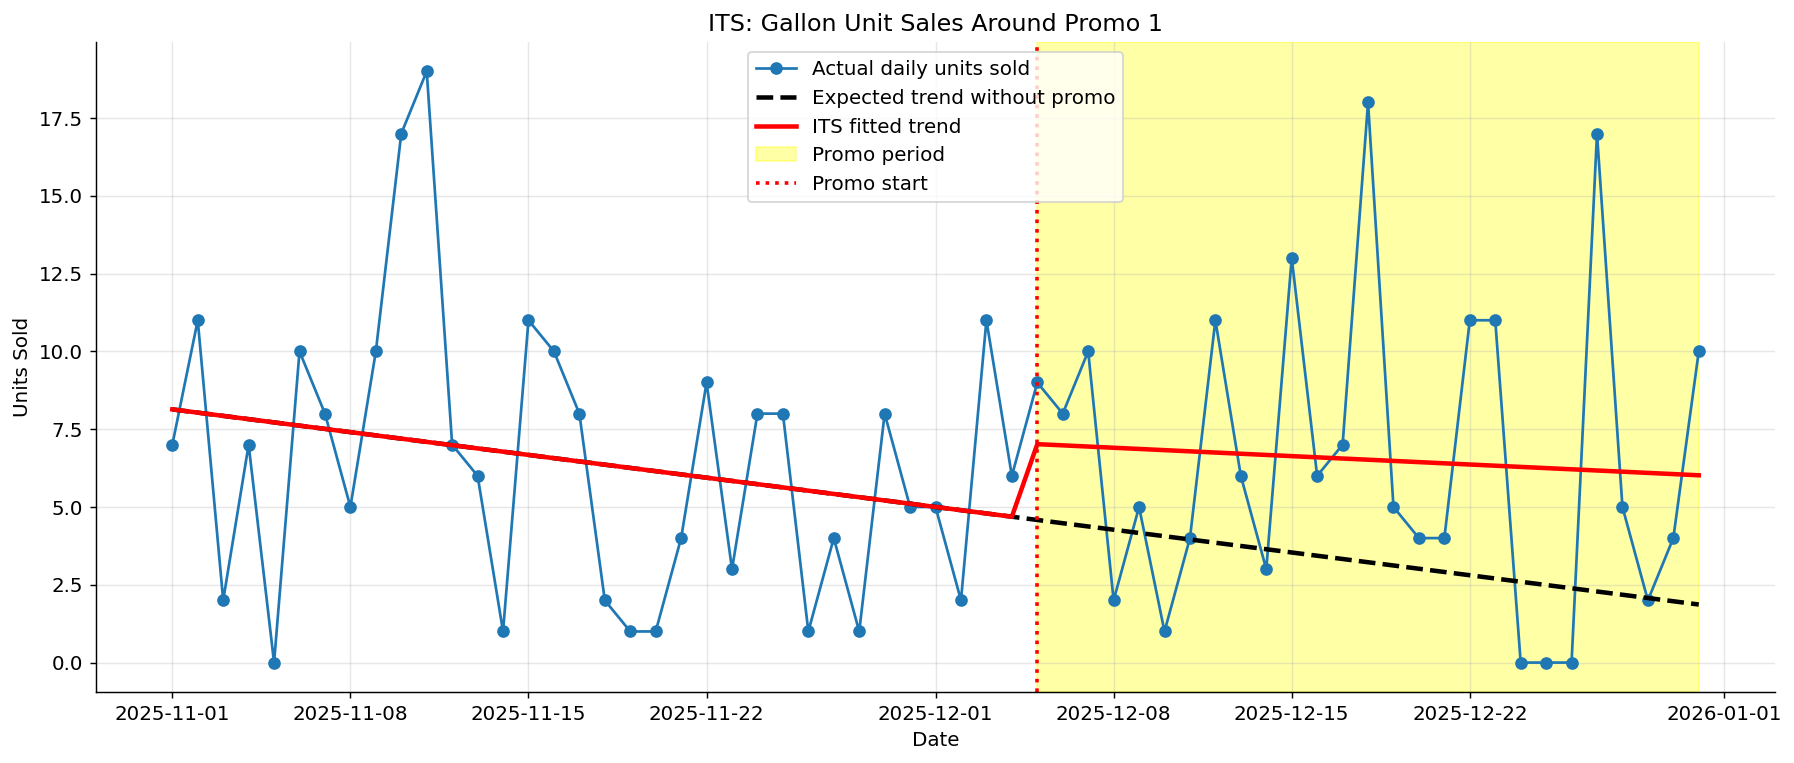


ITS: Gallon Unit Sales Around Promo 1
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            8.1361      1.572      5.176      0.000       4.988      11.284
time                -0.1045      0.082     -1.276      0.207      -0.268       0.059
promo                2.4356      2.403      1.013      0.315      -2.377       7.248
time_after_promo     0.0660      0.142      0.466      0.643      -0.218       0.350

Interpretation:
Pre-promo daily trend slope: -0.105 units/day
Immediate promo level change: 2.436 units
Promo-period slope change: 0.066 units/day


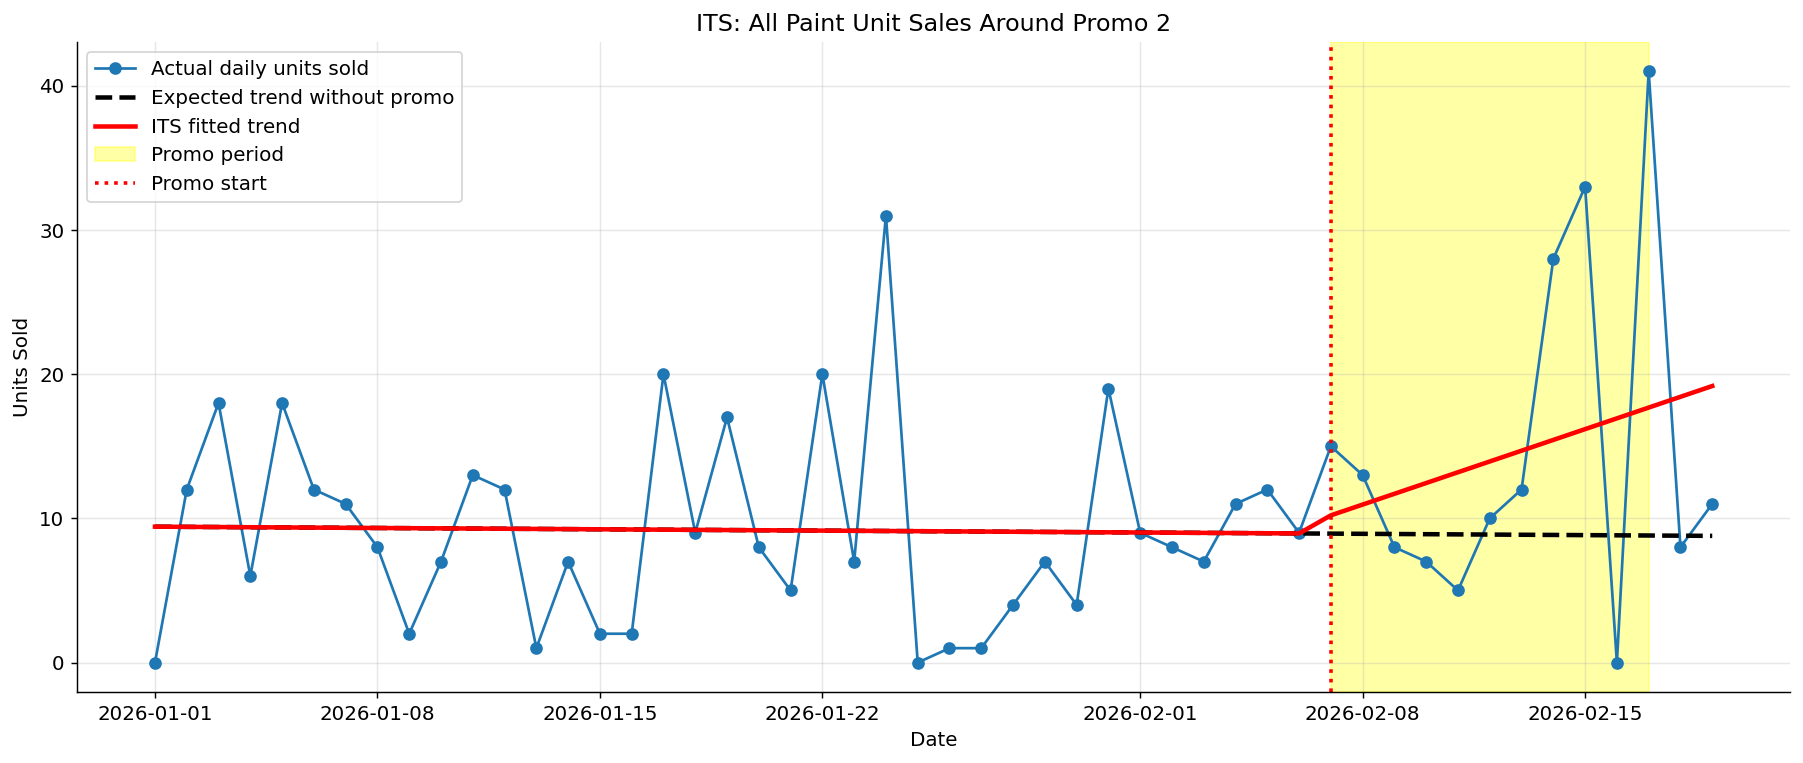


ITS: All Paint Unit Sales Around Promo 2
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            9.4239      2.736      3.444      0.001       3.917      14.931
time                -0.0130      0.131     -0.100      0.921      -0.276       0.250
promo                1.2673      5.284      0.240      0.812      -9.369      11.904
time_after_promo     0.7603      0.643      1.183      0.243      -0.534       2.054

Interpretation:
Pre-promo daily trend slope: -0.013 units/day
Immediate promo level change: 1.267 units
Promo-period slope change: 0.760 units/day


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Load data
df = pd.read_csv("../data/feature_engineered_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Promo windows
PROMO_1_START = pd.Timestamp("2025-12-05")
PROMO_1_END = pd.Timestamp("2025-12-31")

PROMO_2_START = pd.Timestamp("2026-02-07")
PROMO_2_END = pd.Timestamp("2026-02-17")


def run_its_plot(data, title, window_start, window_end, promo_start, promo_end):
    """
    Interrupted Time Series:
    Quantity = intercept + time trend + promo level shift + promo slope change
    """

    # Daily sales
    daily = (
        data.groupby("Date")["Quantity"]
        .sum()
        .sort_index()
        .asfreq("D", fill_value=0)
        .reset_index()
    )

    # Keep local window
    daily = daily[
        (daily["Date"] >= window_start) &
        (daily["Date"] <= window_end)
    ].copy()

    # ITS variables
    daily["time"] = np.arange(len(daily))
    daily["promo"] = (daily["Date"] >= promo_start).astype(int)
    daily["time_after_promo"] = np.where(
        daily["Date"] >= promo_start,
        daily["time"] - daily.loc[daily["Date"] >= promo_start, "time"].min(),
        0
    )

    # Regression
    model = smf.ols(
        "Quantity ~ time + promo + time_after_promo",
        data=daily
    ).fit()

    # Predictions
    daily["fitted_its"] = model.predict(daily)

    # Counterfactual trend: what the pre-promo trend predicts without promo
    counterfactual = daily.copy()
    counterfactual["promo"] = 0
    counterfactual["time_after_promo"] = 0
    daily["counterfactual_no_promo"] = model.predict(counterfactual)

    # Plot
    plt.figure(figsize=(14, 6))

    plt.plot(
        daily["Date"],
        daily["Quantity"],
        marker="o",
        linewidth=1.5,
        label="Actual daily units sold"
    )

    plt.plot(
        daily["Date"],
        daily["counterfactual_no_promo"],
        linestyle="--",
        linewidth=2.5,
        color="black",
        label="Expected trend without promo"
    )

    plt.plot(
        daily["Date"],
        daily["fitted_its"],
        linewidth=2.5,
        color="red",
        label="ITS fitted trend"
    )

    plt.axvspan(
        promo_start,
        promo_end,
        color="yellow",
        alpha=0.35,
        label="Promo period"
    )

    plt.axvline(
        promo_start,
        color="red",
        linestyle=":",
        linewidth=2,
        label="Promo start"
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Units Sold")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n" + title)
    print(model.summary().tables[1])

    print("\nInterpretation:")
    print(f"Pre-promo daily trend slope: {model.params['time']:.3f} units/day")
    print(f"Promo level change: {model.params['promo']:.3f} units")
    print(f"Promo-period slope change: {model.params['time_after_promo']:.3f} units/day")


# -------------------------
# Graph 1: Promo 1, Gallons only
# -------------------------
gallons_only = df[df["Size"] == "Gallon"].copy()

run_its_plot(
    data=gallons_only,
    title="ITS: Gallon Unit Sales Around Promo 1",
    window_start=pd.Timestamp("2025-11-01"),
    window_end=pd.Timestamp("2025-12-31"),
    promo_start=PROMO_1_START,
    promo_end=PROMO_1_END
)


# -------------------------
# Graph 2: Promo 2, All paint
# -------------------------
# Adjust this list if your Size values differ
paint_sizes = ["Gallon", "5 Gallon", "Quart", "Pint", "Half Pint", "Sample"]

all_paint = df[df["Size"].isin(paint_sizes)].copy()

run_its_plot(
    data=all_paint,
    title="ITS: All Paint Unit Sales Around Promo 2",
    window_start=pd.Timestamp("2026-01-01"),
    window_end=pd.Timestamp("2026-02-28"),
    promo_start=PROMO_2_START,
    promo_end=PROMO_2_END
)